In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

import scanpy as sc
import pandas as pd
import seaborn as sb
import numpy as np
import anndata as ann

import torch
from rich import print

from collections import defaultdict
from scipy.io import mmread
from scipy.sparse import csr_matrix
import pickle as pkl

from sklearn.metrics.pairwise import euclidean_distances
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

import gc

pd.set_option('display.max_columns', None)

# Reproducibility
import scvi
from scvi.external import SysVI

# Define the path to the directory you want to change to
new_directory = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/H2M_sysVI/sysVI_integration/original_integration/'

# Use os.chdir() to change the working directory
os.chdir(new_directory)

scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.1.1

In [2]:
# Define a nice color map for gene expression
colors2 = plt.cm.PuRd(np.linspace(0, 1, 128))  # Use PuRd color map for deep red/purple color
colors3 = plt.cm.Greys_r(np.linspace(0.7, 0.8, 20))  # Greys for low values
colorsComb = np.vstack([colors3, colors2])
mymap = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

In [3]:
#Define a nice colour map for gene expression
colors2 = plt.cm.plasma(np.linspace(0, 1, 128))
colors3 = plt.cm.Greys_r(np.linspace(0.7,0.8,20))
colorsComb = np.vstack([colors3, colors2])
mymap2 = colors.LinearSegmentedColormap.from_list('my_colormap', colorsComb)

In [4]:
plt.rcParams['figure.figsize']=(5,5) #rescale figures
sc.settings.verbosity = 3
sc.set_figure_params(scanpy=True, dpi=100, dpi_save=300,transparent=True, fontsize=12) #color_map=mymap2)
#sc.settings.figdir = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/MM_sysVI_cell_type_refined/NEW_figures/'
sc.logging.print_header()

scanpy==1.9.8 anndata==0.10.5.post1 umap==0.5.5 numpy==1.26.3 scipy==1.11.4 pandas==2.2.0 scikit-learn==1.4.1.post1 statsmodels==0.14.1 igraph==0.11.4 louvain==0.8.2 pynndescent==0.5.11


# Start

In [6]:
adata_hs = sc.read_h5ad('/groups/kadams23/eaboelno/h5ad_backup/scVI_human_allgenes_WORKING.h5ad')
adata_hs

AnnData object with n_obs × n_vars = 321566 × 29040
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 's_score', 'g2m_score', 'phase', 'cell_cycle_diff', 'type_fine', 'type_broad', 'cluster_zoom', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'Microglia', 'DAM', 'Macrophages', 'BAM', 'Monocytes', 'DC

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


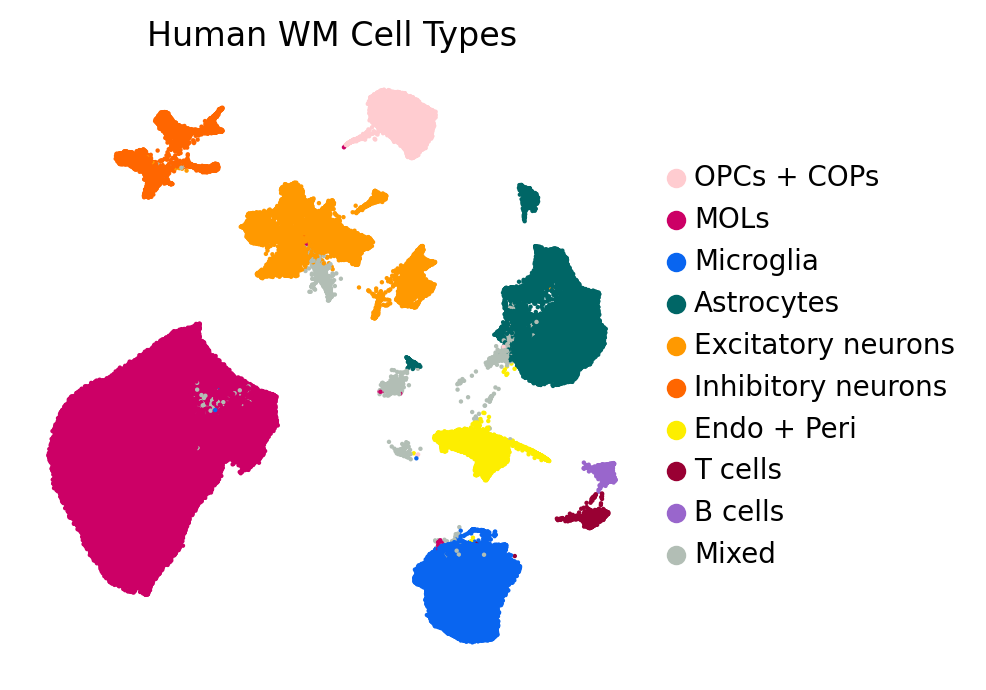

In [7]:
#Visualize the clustering and how this is reflected by different technical covariate
sc.pl.umap(adata_hs, color=['cluster_annotation'], legend_fontsize =float(10) , wspace=0.6,
           legend_fontweight= 'bold', frameon= False , legend_fontoutline=1, s=10,
           title='Human WM Cell Types')  

In [8]:
adata_mm = sc.read_h5ad('/groups/kadams23/eaboelno/h5ad_backup/adata_mm_all_annot_UPDATED.h5ad')
adata_mm

AnnData object with n_obs × n_vars = 112017 × 23660
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 's_score', 'g2m_score', 'phase', 'type_fine', 'type_broad', 'cluster_zoom', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_cycle_diff', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'system_map', 'sys_leiden_0.5', 'sys_leiden_1', 'sys_leiden_1.5', 'sys_leiden_2', 'indiv_treatment_time', 'lesion_status', 'lesion_condition', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Microglia', 'DAM', 'Macropha

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


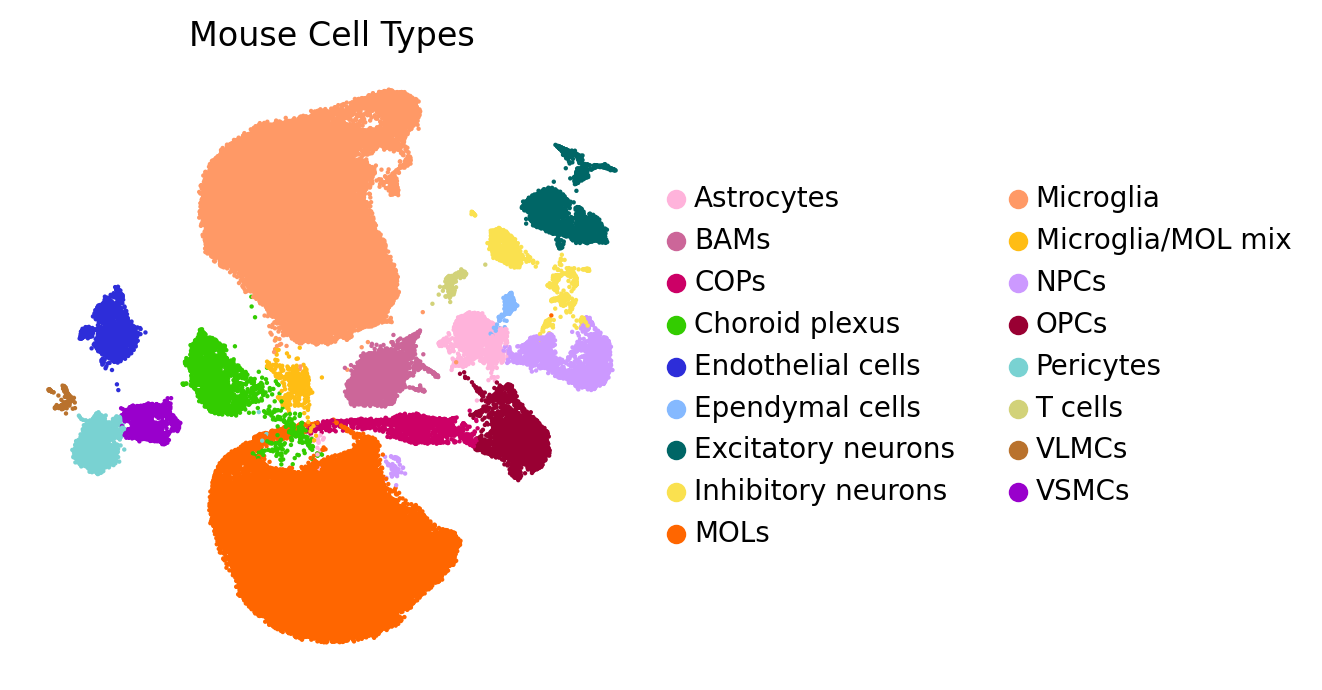

In [9]:
#Visualize the clustering and how this is reflected by different technical covariate
sc.pl.umap(adata_mm, color=['cluster_annotation'], legend_fontsize =float(10) , wspace=0.6,
           legend_fontweight= 'bold', frameon= False , legend_fontoutline=1, s=10,
           title='Mouse Cell Types')  

## Harmonize data

In [21]:
del adata_hs.uns
del adata_hs.obsm
del adata_hs.obsp
del adata_hs.var
adata_hs

AnnData object with n_obs × n_vars = 321566 × 29040
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 's_score', 'g2m_score', 'phase', 'cell_cycle_diff', 'type_fine', 'type_broad', 'cluster_zoom', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'Microglia', 'DAM', 'Macrophages', 'BAM', 'Monocytes', 'DC

In [22]:
del adata_mm.uns
del adata_mm.obsm
del adata_mm.obsp
del adata_mm.var
adata_mm

AnnData object with n_obs × n_vars = 112017 × 23660
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 's_score', 'g2m_score', 'phase', 'type_fine', 'type_broad', 'cluster_zoom', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_cycle_diff', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'system_map', 'sys_leiden_0.5', 'sys_leiden_1', 'sys_leiden_1.5', 'sys_leiden_2', 'indiv_treatment_time', 'lesion_status', 'lesion_condition', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'Microglia', 'DAM', 'Macropha

In [23]:
def delete_obs_columns(adata_hs, columns_to_delete):
    """
    Delete specified columns from the .obs attribute of an AnnData object.

    Parameters:
    adata (AnnData): The AnnData object.
    columns_to_delete (list): List of column names to delete from .obs.

    Returns:
    AnnData: The updated AnnData object with specified columns removed.
    """
    # Check if the columns exist in .obs before attempting to delete
    for col in columns_to_delete:
        if col in adata_hs.obs:
            adata_hs.obs.drop(columns=columns_to_delete, inplace=True)
            print(f"Deleted column: {col}")
        else:
            print(f"Column '{col}' not found in .obs")

    return adata_hs

# List of columns to delete
columns_to_delete = ['s_score', 'g2m_score', 'phase', 'cluster_zoom', 
                     'cell_cycle_diff', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 
                     'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 
                     'total_counts_ribo', 'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 
                     'pct_counts_hb','Microglia', 'DAM', 'Macrophages', 'BAM', 'Monocytes', 'DCs', 'NKT cells', 
                     'T cells', 'B cells', 'Neutrophils', 'Neurons', 'OPCs', 'COPs', 'MOL', 'Astrocytes', 
                     'Pericytes', 'VSMCs', 'VLMCs', 'VECV', 'scVI_leiden_0.5', 'scVI_leiden_1',
                    'cell_leiden_annotated', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito',]

# Call the function to delete these columns
adata_hs = delete_obs_columns(adata_hs, columns_to_delete)
adata_hs

Deleted column: s_score

Column 'g2m_score' not found in .obs

Column 'phase' not found in .obs

Column 'cluster_zoom' not found in .obs

Column 'cell_cycle_diff' not found in .obs

...

Column 'cell_leiden_annotated' not found in .obs

Column 'total_counts_mito' not found in .obs

Column 'log1p_total_counts_mito' not found in .obs

Column 'pct_counts_mito' not found in .obs

AnnData object with n_obs × n_vars = 321566 × 29040
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    layers: 'counts', 'log1p_norm'

In [24]:
def delete_obs_columns(adata_mm, columns_to_delete):
    """
    Delete specified columns from the .obs attribute of an AnnData object.

    Parameters:
    adata (AnnData): The AnnData object.
    columns_to_delete (list): List of column names to delete from .obs.

    Returns:
    AnnData: The updated AnnData object with specified columns removed.
    """
    # Check if the columns exist in .obs before attempting to delete
    for col in columns_to_delete:
        if col in adata_mm.obs:
            adata_mm.obs.drop(columns=columns_to_delete, inplace=True)
            print(f"Deleted column: {col}")
        else:
            print(f"Column '{col}' not found in .obs")

    return adata_mm

# List of columns to delete
columns_to_delete = ['s_score', 'g2m_score', 'phase', 'cluster_zoom', 
                     'cell_cycle_diff', 'sys_leiden_0.5', 'sys_leiden_1', 'sys_leiden_1.5', 'sys_leiden_2', 
                     'indiv_treatment_time', 'lesion_status', 'lesion_condition', 'log1p_n_genes_by_counts', 
                     'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 
                     'log1p_total_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 
                     'Microglia', 'DAM', 'Macrophages', 'BAM', 'Monocytes', 'DCs', 'NKT cells', 'T cells', 
                     'B cells', 'Neutrophils', 'Neurons', 'OPCs', 'COPs', 'MOL', 'Astrocytes', 'Pericytes', 
                     'VSMCs', 'VLMCs', 'VECV', 'cell_leiden_annotated', 
                     'Neuroblasts', 'Endothelial', 'Choroid plexus', 'Ependymal', 
                     'common_innate_immunity_signature', 'IRAS1', 'IRAS2', 
                     'MOLs_highlight', 'S_phase_cells', 'S phase', 'system_map']

# Call the function to delete these columns
adata_mm = delete_obs_columns(adata_mm, columns_to_delete)
adata_mm

Deleted column: s_score

Column 'g2m_score' not found in .obs

Column 'phase' not found in .obs

Column 'cluster_zoom' not found in .obs

Column 'cell_cycle_diff' not found in .obs

...

Column 'MOLs_highlight' not found in .obs

Column 'S_phase_cells' not found in .obs

Column 'S phase' not found in .obs

Column 'system_map' not found in .obs

AnnData object with n_obs × n_vars = 112017 × 23660
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    layers: 'counts', 'log1p_norm'

In [25]:
def compare_obs_columns(adata1, adata2, name1="adata1", name2="adata2"):
    # Extract the .obs column names from both AnnData objects
    obs_columns_1 = set(adata1.obs.columns)
    obs_columns_2 = set(adata2.obs.columns)

    # Find columns unique to each object
    unique_to_adata1 = obs_columns_1 - obs_columns_2
    unique_to_adata2 = obs_columns_2 - obs_columns_1

    # Print results
    if unique_to_adata1:
        print(f"Columns unique to {name1}:")
        print(unique_to_adata1)
    else:
        print(f"No unique columns in {name1}")

    if unique_to_adata2:
        print(f"Columns unique to {name2}:")
        print(unique_to_adata2)
    else:
        print(f"No unique columns in {name2}")
        
# Usage example:
compare_obs_columns(adata_hs, adata_mm, name1="adata_hs", name2="adata_mm")

No unique columns in adata_hs

No unique columns in adata_mm

## Set orthos

In [5]:
# Read the CSV file
mart = pd.read_csv('/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/H2M_sysVI/sysVI_integration/mart_export_unique.txt')

# Rename the columns
mart = mart.rename(columns={
    'Gene stable ID': 'eid_hs',
    'Gene name': 'gene_hs',
    'Mouse gene stable ID': 'eid_mm',
    'Mouse gene name': 'gene_mm'
})

# Optionally, display the first few rows to check the data
print(mart.head())

length_of_mart = len(mart)
print(f"The length of the mart DataFrame is: {length_of_mart}")

eid_hs  gene_hs              eid_mm  gene_mm
0  ENSG00000198888   MT-ND1  ENSMUSG00000064341   mt-Nd1
1  ENSG00000198763   MT-ND2  ENSMUSG00000064345   mt-Nd2
2  ENSG00000198804   MT-CO1  ENSMUSG00000064351   mt-Co1
3  ENSG00000198712   MT-CO2  ENSMUSG00000064354   mt-Co2
4  ENSG00000228253  MT-ATP8  ENSMUSG00000064356  mt-Atp8

The length of the mart DataFrame is: 25768

In [27]:
# One to one orthologues - dont have same mm/hs gene in the table 2x
oto_orthologues=mart[~mart.duplicated('eid_mm',keep=False).values & 
               ~mart.duplicated('eid_hs',keep=False).values]

length_of_mart = len(oto_orthologues)
print(f"The length of the mart DataFrame is: {length_of_mart}")

The length of the mart DataFrame is: 17140

In [28]:
# Find shared genes in full dataframes for OLs:
gene_hs=set(adata_hs.var_names)
gene_mm=set(adata_mm.var_names)
shared_orthologues=oto_orthologues.query('gene_hs in @gene_hs')
shared_orthologues=shared_orthologues.query('gene_mm in @gene_mm')
print('N shared:',shared_orthologues.shape[0])

N shared: 14311

In [29]:
# Find shared genes in full dataframes for OLs:
gene_mm=set(adata_mm.var_names)
shared_orthologues=shared_orthologues.query('gene_mm in @gene_mm')
print('N shared:',shared_orthologues.shape[0])

N shared: 14311

In [30]:
# Subset adatas to shared HVGs
# This already ensures same gene order
adata_hs=adata_hs[:,shared_orthologues.gene_hs]
adata_hs

View of AnnData object with n_obs × n_vars = 321566 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    layers: 'counts', 'log1p_norm'

In [31]:
adata_mm=adata_mm[:,shared_orthologues.gene_mm]
adata_mm

View of AnnData object with n_obs × n_vars = 112017 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    layers: 'counts', 'log1p_norm'

In [32]:
del adata_hs.var

In [33]:
adata_hs.var['gene_name_original'] = adata_hs.var.index

In [34]:
# Now, perform the merge with shared_orthologues
adata_hs.var = adata_hs.var.merge(
    shared_orthologues,
    left_on='gene_name_original',  # Column in adata_hs.var
    right_on='gene_hs',            # Column in shared_orthologues
    how='left'                     # Use left join to keep all entries in adata_hs.var
)

print(adata_hs.var.head())

gene_name_original           eid_hs  gene_hs              eid_mm  gene_mm
0             MT-ND1  ENSG00000198888   MT-ND1  ENSMUSG00000064341   mt-Nd1
1             MT-ND2  ENSG00000198763   MT-ND2  ENSMUSG00000064345   mt-Nd2
2             MT-CO1  ENSG00000198804   MT-CO1  ENSMUSG00000064351   mt-Co1
3             MT-CO2  ENSG00000198712   MT-CO2  ENSMUSG00000064354   mt-Co2
4            MT-ATP8  ENSG00000228253  MT-ATP8  ENSMUSG00000064356  mt-Atp8

In [35]:
# Reset the index to 'gene_name_original'
adata_hs.var.set_index('gene_name_original', inplace=True)

# Remove the index title
adata_hs.var.rename_axis(index=None, inplace=True)
adata_hs.var[:5]

,eid_hs,gene_hs,eid_mm,gene_mm
MT-ND1,ENSG00000198888,MT-ND1,ENSMUSG00000064341,mt-Nd1
MT-ND2,ENSG00000198763,MT-ND2,ENSMUSG00000064345,mt-Nd2
MT-CO1,ENSG00000198804,MT-CO1,ENSMUSG00000064351,mt-Co1
MT-CO2,ENSG00000198712,MT-CO2,ENSMUSG00000064354,mt-Co2
MT-ATP8,ENSG00000228253,MT-ATP8,ENSMUSG00000064356,mt-Atp8


In [36]:
del adata_mm.var

In [37]:
adata_mm.var['gene_name_original'] = adata_mm.var.index

In [38]:
# Now, perform the merge with shared_orthologues
adata_mm.var = adata_mm.var.merge(
    shared_orthologues,
    left_on='gene_name_original',  # Column in adata_hs.var
    right_on='gene_mm',            # Column in shared_orthologues
    how='left'                     # Use left join to keep all entries in adata_hs.var
)

print(adata_mm.var.head())

gene_name_original           eid_hs  gene_hs              eid_mm  gene_mm
0             mt-Nd1  ENSG00000198888   MT-ND1  ENSMUSG00000064341   mt-Nd1
1             mt-Nd2  ENSG00000198763   MT-ND2  ENSMUSG00000064345   mt-Nd2
2             mt-Co1  ENSG00000198804   MT-CO1  ENSMUSG00000064351   mt-Co1
3             mt-Co2  ENSG00000198712   MT-CO2  ENSMUSG00000064354   mt-Co2
4            mt-Atp8  ENSG00000228253  MT-ATP8  ENSMUSG00000064356  mt-Atp8

In [39]:
# Reset the index to 'gene_name_original'
adata_mm.var.set_index('gene_name_original', inplace=True)

# Remove the index title
adata_mm.var.rename_axis(index=None, inplace=True)
adata_mm.var[:5]

,eid_hs,gene_hs,eid_mm,gene_mm
mt-Nd1,ENSG00000198888,MT-ND1,ENSMUSG00000064341,mt-Nd1
mt-Nd2,ENSG00000198763,MT-ND2,ENSMUSG00000064345,mt-Nd2
mt-Co1,ENSG00000198804,MT-CO1,ENSMUSG00000064351,mt-Co1
mt-Co2,ENSG00000198712,MT-CO2,ENSMUSG00000064354,mt-Co2
mt-Atp8,ENSG00000228253,MT-ATP8,ENSMUSG00000064356,mt-Atp8


In [40]:
# Create a new index using the 'gene_hs' column while keeping the original column
adata_mm.var['gene_hs_index'] = adata_mm.var['gene_hs']  # Create a copy of the 'gene_hs' column
adata_mm.var.set_index('gene_hs_index', inplace=True)  # Set the new column as index

# Display the updated adata_mm.var to confirm the changes
print("\nUpdated adata_mm.var with 'gene_hs' as index:")
print(adata_mm.var.head())

Updated adata_mm.var with 'gene_hs' as index:

eid_hs  gene_hs              eid_mm  gene_mm
gene_hs_index                                                       
MT-ND1         ENSG00000198888   MT-ND1  ENSMUSG00000064341   mt-Nd1
MT-ND2         ENSG00000198763   MT-ND2  ENSMUSG00000064345   mt-Nd2
MT-CO1         ENSG00000198804   MT-CO1  ENSMUSG00000064351   mt-Co1
MT-CO2         ENSG00000198712   MT-CO2  ENSMUSG00000064354   mt-Co2
MT-ATP8        ENSG00000228253  MT-ATP8  ENSMUSG00000064356  mt-Atp8

In [41]:
adata_hs.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/hs_converted_balanced.h5ad')
adata_hs

AnnData object with n_obs × n_vars = 321566 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    var: 'eid_hs', 'gene_hs', 'eid_mm', 'gene_mm'
    layers: 'counts', 'log1p_norm'

In [42]:
adata_mm.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/mm_converted_balanced.h5ad')
adata_mm

AnnData object with n_obs × n_vars = 112017 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    var: 'eid_hs', 'gene_hs', 'eid_mm', 'gene_mm'
    layers: 'counts', 'log1p_norm'

# RESTART FROM HERE

In [2]:
import os
import tempfile

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm, colors

import scanpy as sc
import pandas as pd
import seaborn as sb
import numpy as np
import anndata as ann

from collections import defaultdict
from scipy.io import mmread
from scipy.sparse import csr_matrix
import pickle as pkl

import gc

pd.set_option('display.max_columns', None)

# Define the path to the directory you want to change to
new_directory = '/afs/crc.nd.edu/user/e/eaboelno/sysVI_analysis/H2M_sysVI/sysVI_integration/original_integration/'

# Use os.chdir() to change the working directory
os.chdir(new_directory)

## Subset to cell types of interest

In [5]:
adata_hs = sc.read_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/hs_converted_balanced.h5ad')
adata_hs

AnnData object with n_obs × n_vars = 321566 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    var: 'eid_hs', 'gene_hs', 'eid_mm', 'gene_mm'
    layers: 'counts', 'log1p_norm'

In [6]:
adata_mm = sc.read_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/mm_converted_balanced.h5ad')
adata_mm

AnnData object with n_obs × n_vars = 112017 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    var: 'eid_hs', 'gene_hs', 'eid_mm', 'gene_mm'
    layers: 'counts', 'log1p_norm'

In [7]:
adata_hs.obs['cluster_annotation'].value_counts()

cluster_annotation
MOLs                  188293
Astrocytes             39306
Microglia              37685
Excitatory neurons     21614
OPCs + COPs            12579
Inhibitory neurons      7893
Endo + Peri             7515
Mixed                   4102
T cells                 1642
B cells                  937
Name: count, dtype: int64

In [8]:
adata_mm.obs['cluster_annotation'].value_counts()

cluster_annotation
Microglia             50339
MOLs                  41140
OPCs + COPs            3846
Endo + Peri            3109
BAMs                   2676
NPCs                   2187
Excitatory neurons     2069
Choroid plexus         1853
Astrocytes             1639
Inhibitory neurons     1077
VSMCs                   997
Microglia/MOL mix       500
T cells                 207
Ependymal cells         204
VLMCs                   174
Name: count, dtype: int64

In [9]:
# Get unique cluster annotations
clusters_mm = set(adata_mm.obs['cluster_annotation'].unique())
clusters_hs = set(adata_hs.obs['cluster_annotation'].unique())

# Find overlaps and differences
overlap = clusters_mm & clusters_hs
only_mm = clusters_mm - clusters_hs
only_hs = clusters_hs - clusters_mm

# Print results
print("Overlap:", sorted(overlap))
print("Only in mouse:", sorted(only_mm))
print("Only in human:", sorted(only_hs))

Overlap:
[
    'Astrocytes',
    'Endo + Peri',
    'Excitatory neurons',
    'Inhibitory neurons',
    'MOLs',
    'Microglia',
    'OPCs + COPs',
    'T cells'
]

Only in mouse:
['BAMs', 'Choroid plexus', 'Ependymal cells', 'Microglia/MOL mix', 'NPCs', 'VLMCs', 'VSMCs']

Only in human:
['B cells', 'Mixed']

In [10]:
# Combine 'cops', 'mols', and 'opcs' into 'mols + cops'
adata_mm.obs['cluster_annotation'] = adata_mm.obs['cluster_annotation'].replace(
    {'COPs': 'OPCs + COPs', 'MOLs': 'MOLs', 'OPCs': 'OPCs + COPs'}
)

adata_mm.obs['cluster_annotation'] = adata_mm.obs['cluster_annotation'].replace(
    {'Endothelial cells': 'Endo + Peri', 'Pericytes': 'Endo + Peri'}
)

sorted(adata_mm.obs['cluster_annotation'].unique())

['Astrocytes',
 'BAMs',
 'Choroid plexus',
 'Endo + Peri',
 'Ependymal cells',
 'Excitatory neurons',
 'Inhibitory neurons',
 'MOLs',
 'Microglia',
 'Microglia/MOL mix',
 'NPCs',
 'OPCs + COPs',
 'T cells',
 'VLMCs',
 'VSMCs']

In [13]:
adata_mm.obs['cluster_annotation'] = adata_mm.obs['cluster_annotation'].replace(
    {'BAMs': 'Microglia'}
)

sorted(adata_mm.obs['cluster_annotation'].unique())

/tmp/2052744.1.gpu/ipykernel_1654316/2707249594.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_mm.obs['cluster_annotation'] = adata_mm.obs['cluster_annotation'].replace(


['Astrocytes',
 'Choroid plexus',
 'Endo + Peri',
 'Ependymal cells',
 'Excitatory neurons',
 'Inhibitory neurons',
 'MOLs',
 'Microglia',
 'Microglia/MOL mix',
 'NPCs',
 'OPCs + COPs',
 'T cells',
 'VLMCs',
 'VSMCs']

In [11]:
sorted(adata_hs.obs['cluster_annotation'].unique())

['Astrocytes',
 'B cells',
 'Endo + Peri',
 'Excitatory neurons',
 'Inhibitory neurons',
 'MOLs',
 'Microglia',
 'Mixed',
 'OPCs + COPs',
 'T cells']

In [14]:
desired_cell_types = ['OPCs + COPs', 'MOLs', "Microglia", 'Astrocytes', 'Endo + Peri', 'Excitatory neurons', 'Inhibitory neurons', 'T cells']
adata_hs_sub = adata_hs[adata_hs.obs['cluster_annotation'].isin(desired_cell_types)].copy()
sc.pp.filter_genes(adata_hs_sub, min_cells=10)
adata_hs_sub

AnnData object with n_obs × n_vars = 316527 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    var: 'eid_hs', 'gene_hs', 'eid_mm', 'gene_mm', 'n_cells'
    layers: 'counts', 'log1p_norm'

In [15]:
desired_cell_types = ['OPCs + COPs', 'MOLs', "Microglia", 'Astrocytes', 'Endo + Peri', 'Excitatory neurons', 'Inhibitory neurons', 'T cells']
adata_mm_sub = adata_mm[adata_mm.obs['cluster_annotation'].isin(desired_cell_types)].copy()
sc.pp.filter_genes(adata_mm_sub, min_cells=10)
adata_mm_sub

filtered out 336 genes that are detected in less than 10 cells


AnnData object with n_obs × n_vars = 106102 × 13975
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    var: 'eid_hs', 'gene_hs', 'eid_mm', 'gene_mm', 'n_cells'
    layers: 'counts', 'log1p_norm'

In [16]:
del adata_hs_sub.raw
del adata_mm_sub.raw

In [17]:
adata_hs_sub.X = adata_hs_sub.layers["counts"]
adata_mm_sub.X = adata_mm_sub.layers["counts"]

In [18]:
adata_hs_sub.raw = adata_hs_sub.copy()
adata_mm_sub.raw = adata_mm_sub.copy()

In [19]:
print(adata_hs_sub.raw.shape)
print(adata_hs_sub.X.shape)
print(adata_mm_sub.raw.shape)
print(adata_mm_sub.X.shape)

(316527, 14311)

(316527, 14311)

(106102, 13975)

(106102, 13975)

## HVGs

In [20]:
adata_hs_sub.X

<316527x14311 sparse matrix of type '<class 'numpy.float64'>'
	with 604303724 stored elements in Compressed Sparse Column format>

In [21]:
adata_mm_sub.X

<106102x13975 sparse matrix of type '<class 'numpy.int64'>'
	with 209307702 stored elements in Compressed Sparse Row format>

In [22]:
# Convert the sparse matrix to float64
adata_mm_sub.X = adata_mm_sub.X.astype(np.float64)
adata_mm_sub.X

<106102x13975 sparse matrix of type '<class 'numpy.float64'>'
	with 209307702 stored elements in Compressed Sparse Row format>

In [23]:
import scipy
adata_mm_sub.X = scipy.sparse.csr_matrix(adata_mm_sub.X)
adata_mm_sub.X

<106102x13975 sparse matrix of type '<class 'numpy.float64'>'
	with 209307702 stored elements in Compressed Sparse Row format>

In [24]:
# HVGs on the final cell subset
sc.pp.highly_variable_genes(
     adata=adata_hs_sub, n_top_genes=3000, layer='log1p_norm', flavor='cell_ranger', batch_key='batch', subset=False)
print(adata_hs_sub.var["highly_variable"].sum())

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: T

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: T

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: T

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: T

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: T

    finished (0:11:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:508: FutureWarning: The provided callable <function nanmean at 0x14978c08c310> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = df.groupby("gene").agg(
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:508: FutureWarning: The provided ca

3000

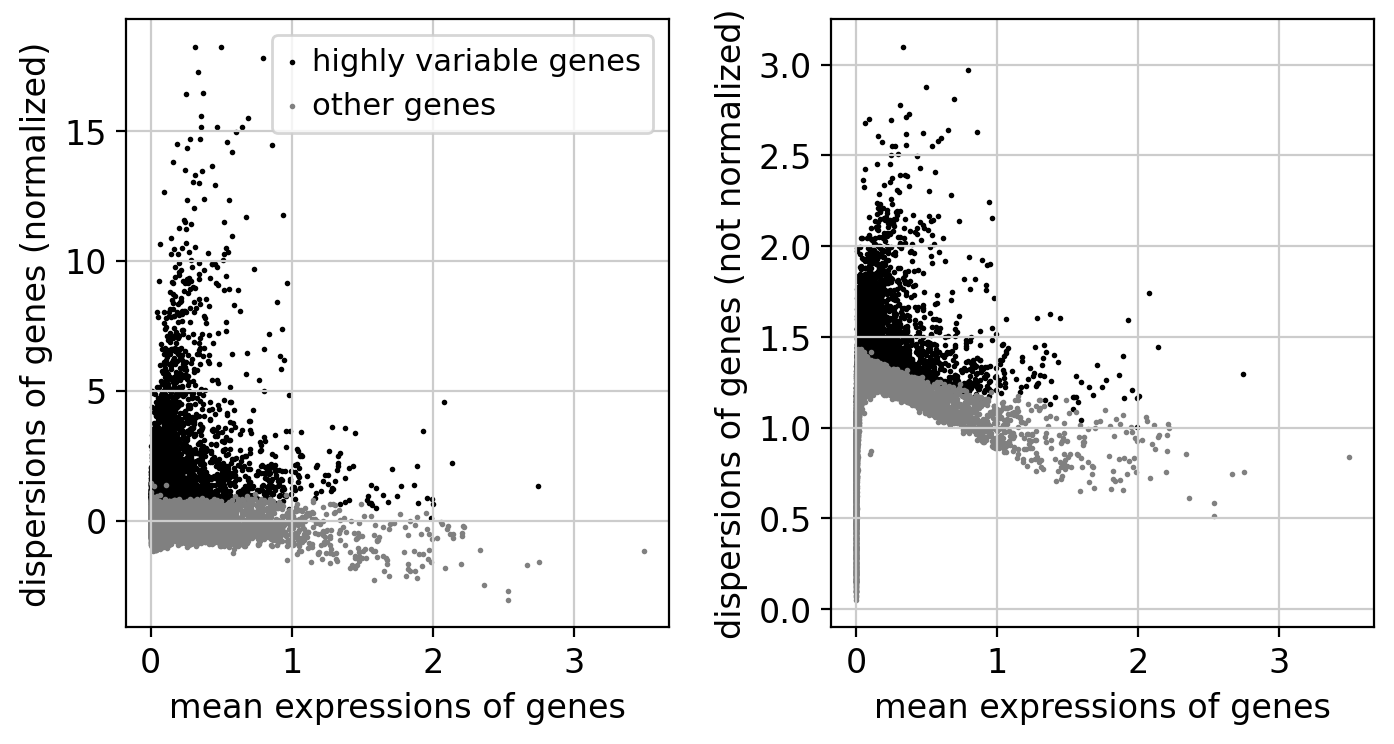

In [25]:
sc.pl.highly_variable_genes(adata_hs_sub)

In [26]:
# HVGs on the final cell subset
sc.pp.highly_variable_genes(
     adata=adata_mm_sub, n_top_genes=3000, layer='log1p_norm', flavor='cell_ranger', batch_key='batch',
    subset=False)
print(adata_mm_sub.var["highly_variable"].sum())

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: T

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: T

    finished (0:00:07)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:258: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:508: FutureWarning: T

3000

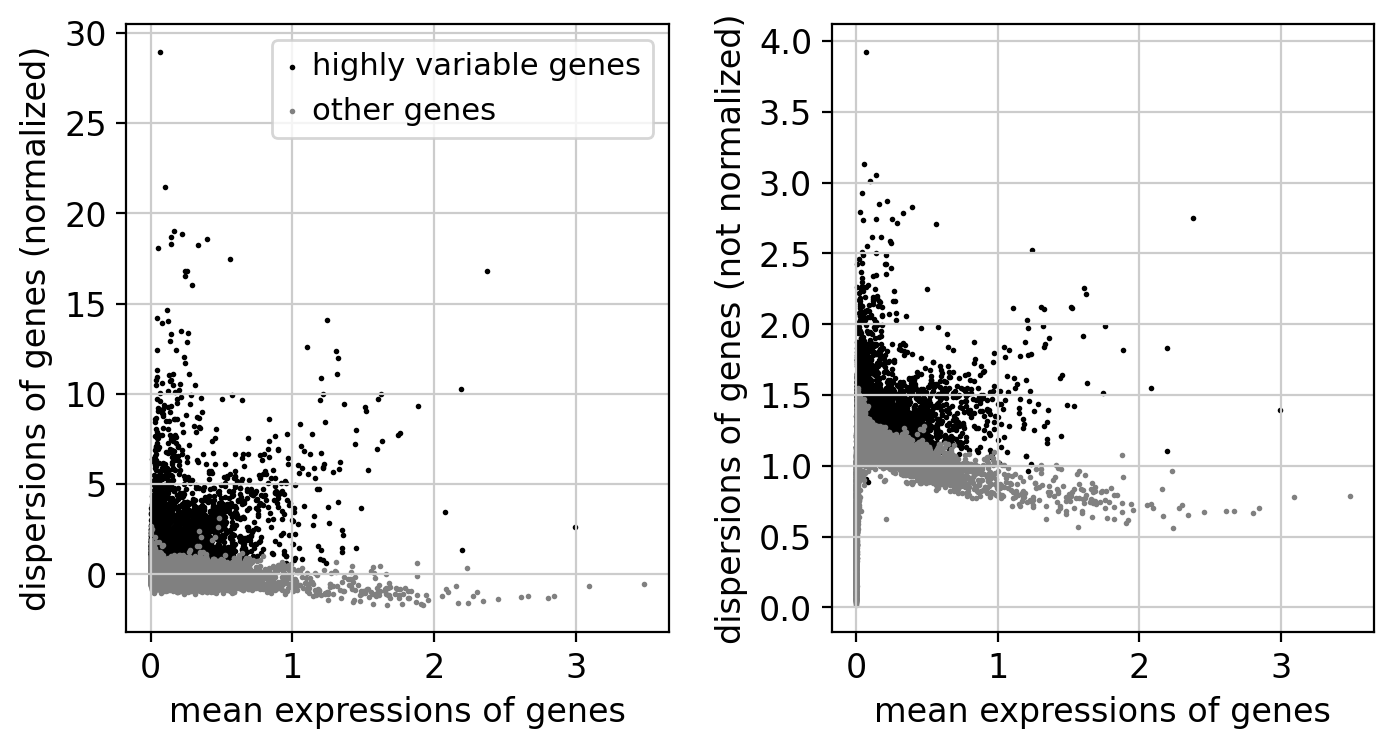

In [27]:
sc.pl.highly_variable_genes(adata_mm_sub)

In [28]:
adata_hs_sub.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/hs_converted_balanced_HVG.h5ad')
adata_hs_sub

AnnData object with n_obs × n_vars = 316527 × 14311
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    var: 'eid_hs', 'gene_hs', 'eid_mm', 'gene_mm', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg'
    layers: 'counts', 'log1p_norm'

In [29]:
adata_mm_sub.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/mm_converted_balanced_HVG.h5ad')
adata_mm_sub

AnnData object with n_obs × n_vars = 106102 × 13975
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    var: 'eid_hs', 'gene_hs', 'eid_mm', 'gene_mm', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg'
    layers: 'counts', 'log1p_norm'

## Reset shared ortho in .X and raw

In [30]:
del adata_hs_sub.raw
del adata_mm_sub.raw

In [31]:
adata_hs_sub.X = adata_hs_sub.layers["counts"]
adata_mm_sub.X = adata_mm_sub.layers["counts"]

In [32]:
adata_hs_sub.raw = adata_hs_sub.copy()
adata_mm_sub.raw = adata_mm_sub.copy()

In [33]:
adata_hs_sub.X.shape

(316527, 14311)

In [34]:
adata_mm_sub.X.shape

(106102, 13975)

In [35]:
print(adata_hs_sub.raw.shape)
print(adata_mm_sub.raw.shape)

(316527, 14311)

(106102, 13975)

In [36]:
print(adata_hs_sub.X[:5, :5])

(0, 0)        4.0
  (1, 0)        1.0
  (0, 1)        2.0
  (1, 1)        1.0
  (2, 1)        4.0
  (0, 2)        1.0
  (3, 2)        1.0
  (0, 3)        9.0
  (2, 3)        1.0
  (3, 3)        2.0
  (4, 3)        4.0
  (0, 4)        1.0

In [37]:
print(adata_mm_sub.X[:5, :5])

(0, 1)        1
  (2, 1)        1
  (2, 3)        1
  (2, 4)        1
  (4, 1)        2
  (4, 3)        1

In [38]:
print(adata_hs_sub.raw.X[:5, :5])

(0, 0)        4.0
  (1, 0)        1.0
  (0, 1)        2.0
  (1, 1)        1.0
  (2, 1)        4.0
  (0, 2)        1.0
  (3, 2)        1.0
  (0, 3)        9.0
  (2, 3)        1.0
  (3, 3)        2.0
  (4, 3)        4.0
  (0, 4)        1.0

In [39]:
print(adata_mm_sub.raw.X[:5, :5])

(0, 1)        1
  (2, 1)        1
  (2, 3)        1
  (2, 4)        1
  (4, 1)        2
  (4, 3)        1

In [40]:
adata_hs_sub.X = adata_hs_sub.layers["log1p_norm"]
adata_mm_sub.X = adata_mm_sub.layers["log1p_norm"]

## Merge

In [41]:
adata_hvg_hs = adata_hs_sub[:, adata_hs_sub.var["highly_variable"]].copy()
adata_hvg_hs

AnnData object with n_obs × n_vars = 316527 × 3000
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'pct_counts_ribo', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    var: 'eid_hs', 'gene_hs', 'eid_mm', 'gene_mm', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg'
    layers: 'counts', 'log1p_norm'

In [42]:
adata_hvg_mm = adata_mm_sub[:, adata_mm_sub.var["highly_variable"]].copy()
adata_hvg_mm

AnnData object with n_obs × n_vars = 106102 × 3000
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    var: 'eid_hs', 'gene_hs', 'eid_mm', 'gene_mm', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'hvg'
    layers: 'counts', 'log1p_norm'

In [43]:
# Shared HVGs
shared_hvgs=list(set(adata_hvg_mm.var_names) & set(adata_hvg_hs.var_names))
len(shared_hvgs)

1796

In [44]:
# Keys adds a category annotation to each observation (row)
adata_merge=sc.concat([adata_hvg_mm[:,shared_hvgs], adata_hvg_hs[:,shared_hvgs]],
                join='outer',
                index_unique='_', keys=['mouse', 'human'])
adata_merge

AnnData object with n_obs × n_vars = 422629 × 1796
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation'
    layers: 'counts', 'log1p_norm'

In [45]:
system_map = {
    '(this study)': '0',
    'Pandey et al. 2022': '1',
    'Shen et al. 2021': '1',
    'Macnair et al. biorxiv': '2'
}

# Update the 'system_map' column based on the mapping
adata_merge.obs['system'] = adata_merge.obs['publication'].map(system_map)

In [46]:
system_map = {
    '0': 'sn-mouse',
    '1': 'sc-mouse',
    '2': 'sn-human'
}

# Update the 'system_map' column based on the mapping
adata_merge.obs['system_map'] = adata_merge.obs['system'].map(system_map)

In [47]:
adata_merge.obs['time'] = adata_merge.obs['time'].astype(str)
adata_merge.obs['batch'] = adata_merge.obs['batch'].astype(str)
adata_merge.obs['exclude_pseudobulk'] = adata_merge.obs['exclude_pseudobulk'].astype(str)
adata_merge.obs['age_at_death'] = adata_merge.obs['age_at_death'].astype(str)
adata_merge.obs['age_scale'] = adata_merge.obs['age_scale'].astype(str)

In [48]:
adata_merge.obs['system'] = adata_merge.obs['system'].astype(str)

In [49]:
adata_merge.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/adata_balanced_merged_3kHVG_unintegrated.h5ad')
adata_merge

AnnData object with n_obs × n_vars = 422629 × 1796
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map'
    layers: 'counts', 'log1p_norm'

In [50]:
sorted(adata_merge.obs['cluster_annotation'].unique()) ##should be 8 cell types

['Astrocytes',
 'Endo + Peri',
 'Excitatory neurons',
 'Inhibitory neurons',
 'MOLs',
 'Microglia',
 'OPCs + COPs',
 'T cells']

# RESTART from sysVI

In [51]:
plt.rcParams['axes.grid'] = False

In [52]:
adata = sc.read_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/adata_balanced_merged_3kHVG_unintegrated.h5ad')
adata

AnnData object with n_obs × n_vars = 422629 × 1796
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map'
    layers: 'counts', 'log1p_norm'

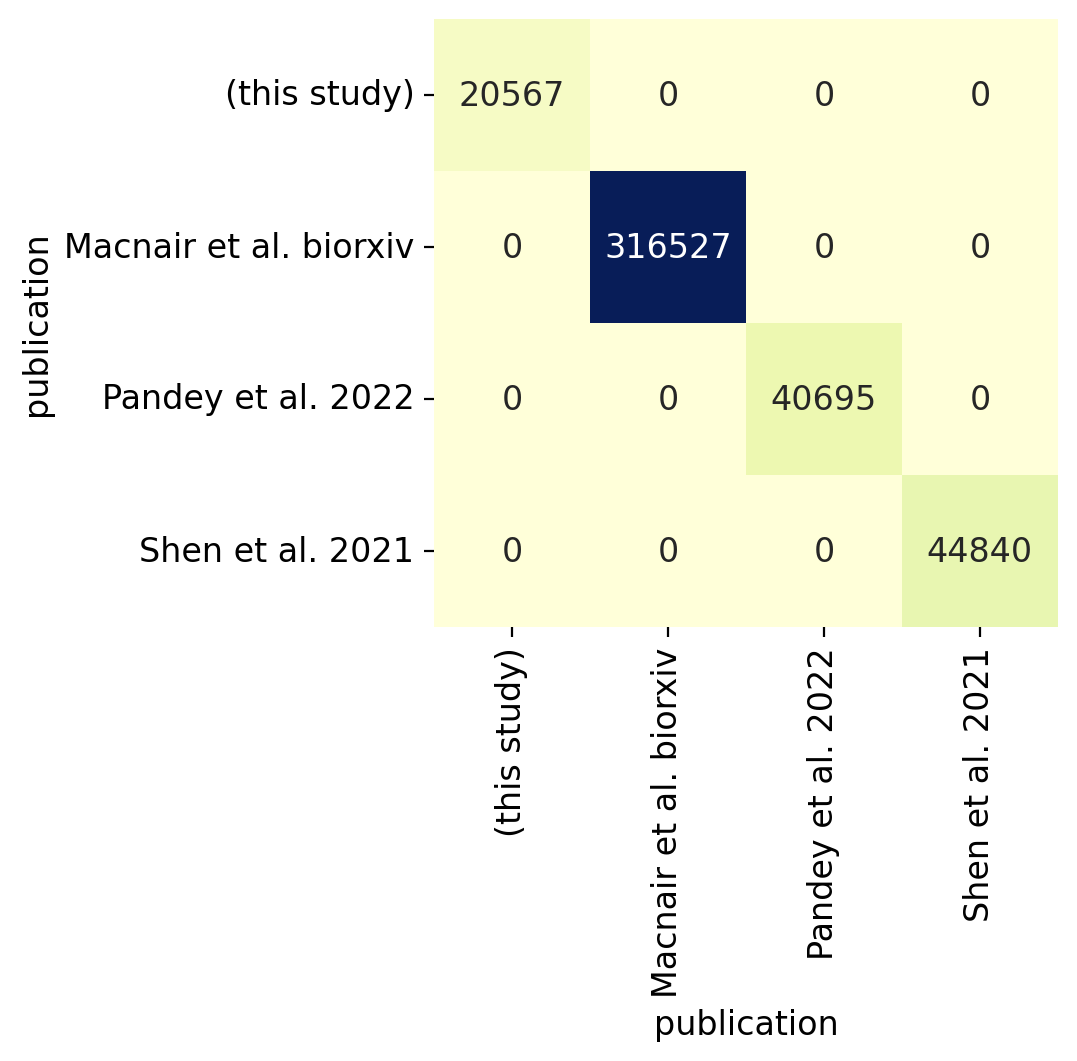

In [53]:
crosstab_df = pd.crosstab(adata.obs.publication, adata.obs.publication)

# Create the heatmap with integer annotations
sb.heatmap(crosstab_df, cmap="YlGnBu", annot=True, fmt="d", cbar=False)

# Show the heatmap
plt.show()

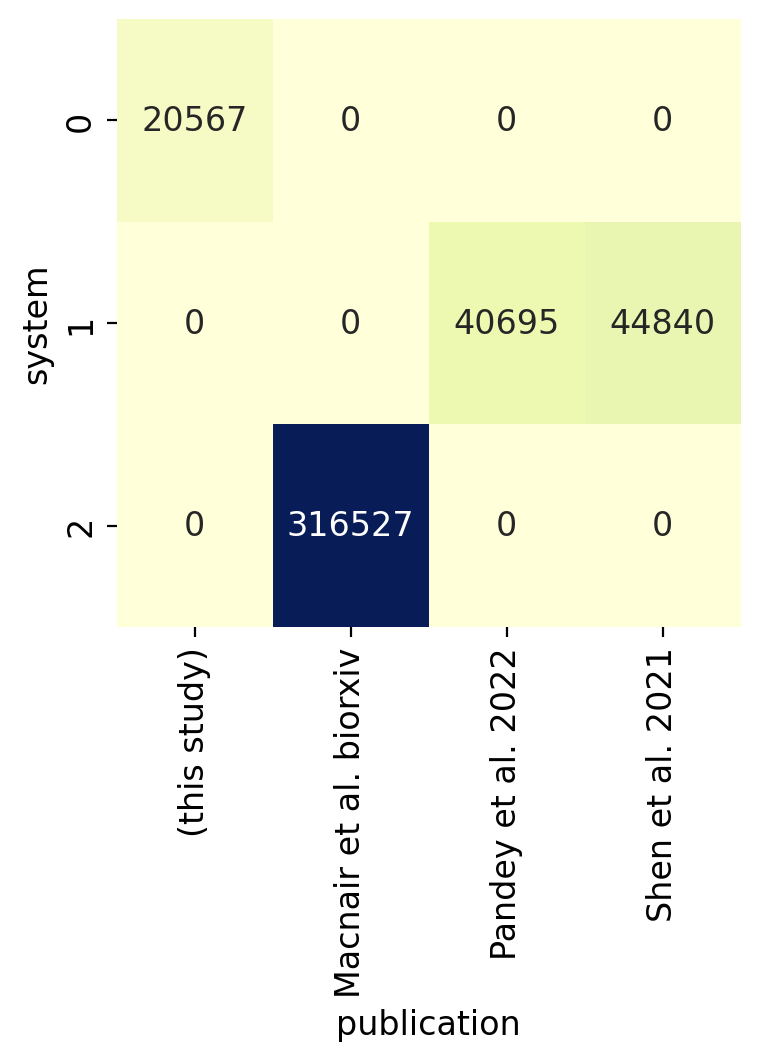

In [54]:
crosstab_df = pd.crosstab(adata.obs.system, adata.obs.publication)

# Create the heatmap with integer annotations
sb.heatmap(crosstab_df, cmap="YlGnBu", annot=True, fmt="d", cbar=False)

# Show the heatmap
plt.show()

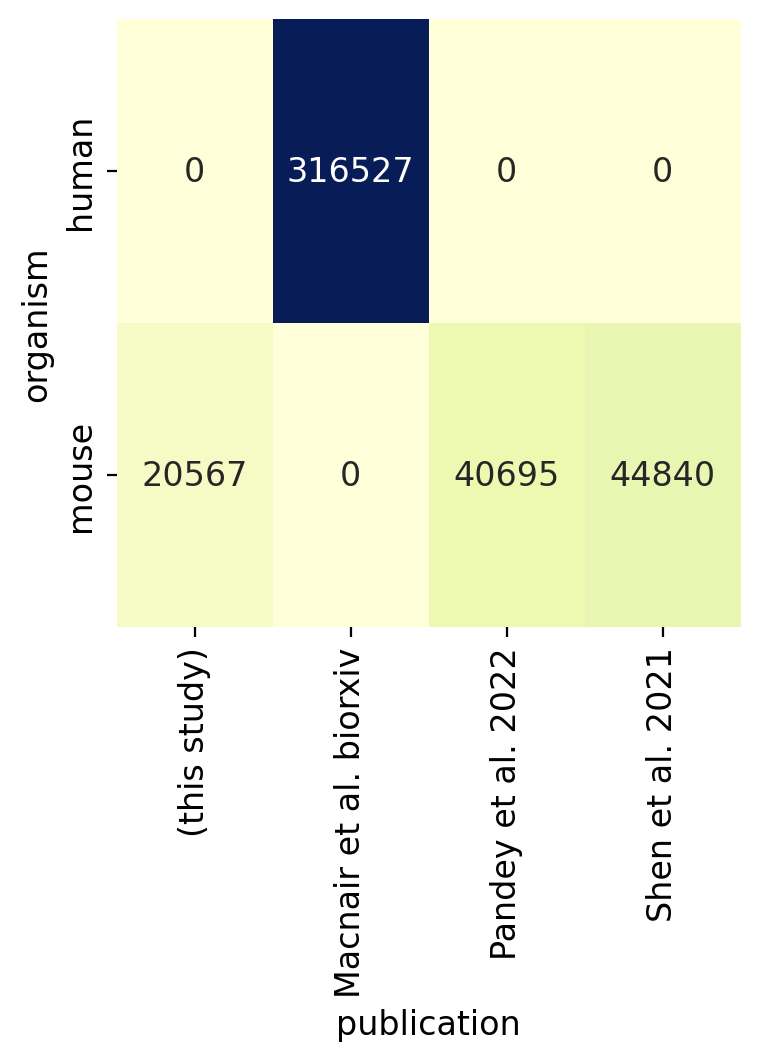

In [55]:
crosstab_df = pd.crosstab(adata.obs.organism, adata.obs.publication)

# Create the heatmap with integer annotations
sb.heatmap(crosstab_df, cmap="YlGnBu", annot=True, fmt="d", cbar=False)

# Show the heatmap
plt.show()

In [56]:
adata.obs['cell_type_eval'].value_counts()

cell_type_eval
oligodendrocytes        229103
microglia                90415
astrocytes               40833
excitatory neurons       24530
opcs + cops              16464
endo + peri               9282
inhibitory neurons        8014
t cells                   1541
vsmcs                     1201
mixed ol + microglia       384
neuroblasts                100
b cells                     98
ependymal                    1
Name: count, dtype: int64

In [57]:
adata.obs['cluster_annotation'].value_counts()

cluster_annotation
MOLs                  229433
Microglia              90700
Astrocytes             40945
Excitatory neurons     23683
OPCs + COPs            16425
Endo + Peri            10624
Inhibitory neurons      8970
T cells                 1849
Name: count, dtype: int64

In [58]:
# Cell counts per organism × cell_type
ct_counts = adata.obs.groupby(["organism","cluster_annotation"]).size().unstack(fill_value=0)

# Cell counts per organism × system
sys_counts = adata.obs.groupby(["organism","system"]).size().unstack(fill_value=0)

# Quick totals
organism_totals = adata.obs["organism"].value_counts()
system_totals = adata.obs["system"].value_counts()
celltype_totals = adata.obs["cluster_annotation"].value_counts()

# Show tables
display(ct_counts.head(10))  # top 10 cell types
display(sys_counts)
display(organism_totals)
display(celltype_totals.head(10))

/tmp/2052744.1.gpu/ipykernel_1654316/1293072853.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_counts = adata.obs.groupby(["organism","cluster_annotation"]).size().unstack(fill_value=0)
/tmp/2052744.1.gpu/ipykernel_1654316/1293072853.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sys_counts = adata.obs.groupby(["organism","system"]).size().unstack(fill_value=0)


cluster_annotation,Astrocytes,Endo + Peri,Excitatory neurons,Inhibitory neurons,MOLs,Microglia,OPCs + COPs,T cells
organism,,,,,,,,
human,39306,7515,21614,7893,188293,37685,12579,1642
mouse,1639,3109,2069,1077,41140,53015,3846,207


system,0,1,2
organism,,,
human,0,0,316527
mouse,20567,85535,0


organism
human    316527
mouse    106102
Name: count, dtype: int64

cluster_annotation
MOLs                  229433
Microglia              90700
Astrocytes             40945
Excitatory neurons     23683
OPCs + COPs            16425
Endo + Peri            10624
Inhibitory neurons      8970
T cells                 1849
Name: count, dtype: int64

/tmp/2052744.1.gpu/ipykernel_1654316/4057883112.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ct_top_counts = subset.groupby(["cluster_annotation","organism"]).size().unstack(fill_value=0)


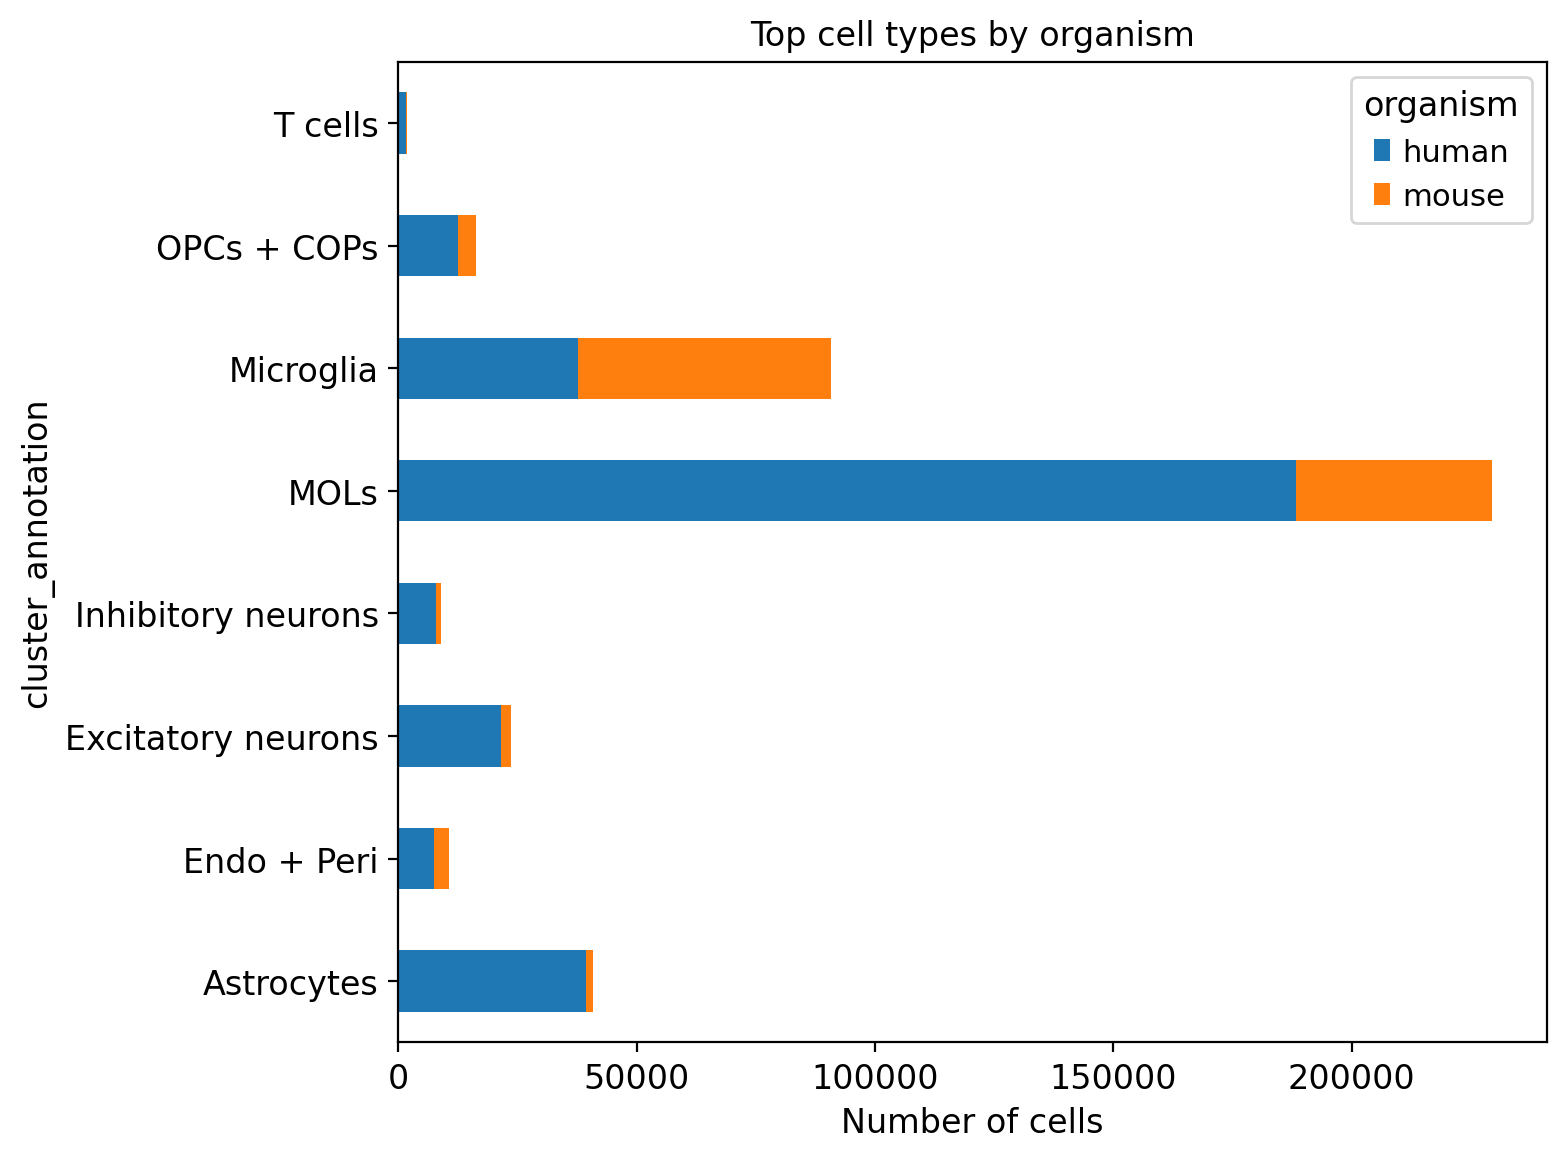

In [59]:
top_cts = celltype_totals.head(15).index  # pick top 15 cell types
subset = adata.obs[adata.obs["cluster_annotation"].isin(top_cts)]

ct_top_counts = subset.groupby(["cluster_annotation","organism"]).size().unstack(fill_value=0)
ct_top_counts.plot(kind="barh", stacked=True, figsize=(8,6))
plt.xlabel("Number of cells")
plt.title("Top cell types by organism")
plt.tight_layout()
plt.show()

In [60]:
# Counts before merging with min_n
counts_raw = adata.obs.groupby(["organism","cluster_annotation","batch"]).size()
print(counts_raw.sort_values(ascending=False).head(20))

/tmp/2052744.1.gpu/ipykernel_1654316/615205965.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_raw = adata.obs.groupby(["organism","cluster_annotation","batch"]).size()


organism  cluster_annotation  batch
human     MOLs                110      8210
                              116      7123
                              122      6653
                              107      6431
mouse     Microglia           26       6379
                              18       5961
                              23       5935
human     MOLs                117      5531
                              48       5346
                              72       5203
                              103      4605
mouse     Microglia           19       4449
          MOLs                11       4406
human     MOLs                70       4111
                              47       4070
                              88       4051
                              118      3983
          Astrocytes          82       3927
          MOLs                49       3792
                              92       3717
dtype: int64

In [61]:
# Count cells per organism × cell type × batch
batch_sizes = (
    adata.obs.groupby(["organism","cluster_annotation","batch"])
    .size()
    .reset_index(name="n_cells")
)

# Sort by size
batch_sizes_sorted = batch_sizes.sort_values("n_cells")

# How many are small (<200 cells, as example)?
threshold = 20
small_batches = batch_sizes_sorted[batch_sizes_sorted["n_cells"] < threshold]

print(f"Total batches: {batch_sizes.shape[0]}")
print(f"Small batches (<{threshold} cells): {small_batches.shape[0]}")

# Optionally: counts per cell type of how many small batches
small_counts_summary = (
    small_batches.groupby(["organism","cluster_annotation"]).size().reset_index(name="n_small_batches")
)
print(small_counts_summary)

/tmp/2052744.1.gpu/ipykernel_1654316/3788247798.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(["organism","cluster_annotation","batch"])


Total batches: 1952

Small batches (<20 cells): 1243

/tmp/2052744.1.gpu/ipykernel_1654316/3788247798.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  small_batches.groupby(["organism","cluster_annotation"]).size().reset_index(name="n_small_batches")


organism  cluster_annotation  n_small_batches
0     human          Astrocytes               32
1     human         Endo + Peri               57
2     human  Excitatory neurons               52
3     human  Inhibitory neurons               65
4     human                MOLs               30
5     human           Microglia               33
6     human         OPCs + COPs               32
7     human             T cells              103
8     mouse          Astrocytes              103
9     mouse         Endo + Peri              104
10    mouse  Excitatory neurons              114
11    mouse  Inhibitory neurons              113
12    mouse                MOLs               92
13    mouse           Microglia               94
14    mouse         OPCs + COPs              100
15    mouse             T cells              119

In [62]:
import numpy as np
import pandas as pd

# 0. prepare batch sizes table
batch_sizes = (
    adata.obs
    .groupby(["organism","cluster_annotation","batch"])
    .size()
    .reset_index(name="n_cells")
)

# --- Part A: show how many batches retained at candidate thresholds ---
def retention_summary(batch_sizes, thresholds=[50,100,200,500,1000,2000]):
    rows = []
    total_batches = batch_sizes.shape[0]
    for t in thresholds:
        kept = batch_sizes[batch_sizes["n_cells"] >= t].shape[0]
        rows.append({"threshold": t, "kept_batches": kept, "dropped_batches": total_batches - kept,
                     "pct_kept": 100*kept/total_batches})
    return pd.DataFrame(rows)

thresholds = [50,100,200,500,1000,2000]
ret_df = retention_summary(batch_sizes, thresholds)
print(ret_df)

# Also show per (organism, cell_type) how many batches would be lost at each threshold
def per_group_retention(batch_sizes, threshold):
    bs = batch_sizes.copy()
    bs["kept"] = (bs["n_cells"] >= threshold).astype(int)
    summary = (
        bs.groupby(["organism","cluster_annotation"])["kept"]
          .agg(total_batches="count", kept_batches="sum")
          .reset_index()
    )
    summary["pct_kept"] = 100*summary["kept_batches"]/summary["total_batches"]
    return summary.sort_values(["organism","pct_kept"])

# Example:
print(per_group_retention(batch_sizes, threshold=200).head(20))

# --- Part B: Conservative subsampling (exclude tiny batches < T, then equal-per-batch) ---
def subsample_conservative(adata, T=200, random_state=42):
    np.random.seed(random_state)
    bs = adata.obs.groupby(["organism","cluster_annotation","batch"]).size().reset_index(name="n_cells")
    # retained batches
    retained = bs[bs["n_cells"] >= T].copy()
    if retained.empty:
        raise ValueError("No batches meet the threshold T.")
    # For each (organism, cell_type), find min batch size across retained batches
    min_per_group = retained.groupby(["organism","cluster_annotation"])["n_cells"].min().reset_index(name="min_n")
    retained = retained.merge(min_per_group, on=["organism","cluster_annotation"])
    keep_idx = []
    for _, row in retained.iterrows():
        org, ct, batch_id, n_cells, min_n = row["organism"], row["cluster_annotation"], row["batch"], row["n_cells"], row["min_n"]
        # indices of that group
        idx = adata.obs.query("organism == @org and cluster_annotation == @ct and batch == @batch_id").index.to_list()
        k = min(min_n, len(idx))
        sampled = list(np.random.choice(idx, size=k, replace=False))
        keep_idx.extend(sampled)
    adata_balanced = adata[keep_idx].copy()
    return adata_balanced, retained

# --- Part C: Compromise subsampling (keep all batches; cap per-batch; then equalize species totals per cell_type) ---
def subsample_compromise(adata, per_batch_cap=2000, random_state=42):
    np.random.seed(random_state)
    bs = adata.obs.groupby(["organism","cluster_annotation","batch"]).size().reset_index(name="n_cells")
    keep_idx = []
    # 1) cap per batch and sample up to cap from each batch
    for _, row in bs.iterrows():
        org, ct, batch_id, n_cells = row["organism"], row["cluster_annotation"], row["batch"], row["n_cells"]
        idx = adata.obs.query("organism == @org and cluster_annotation == @ct and batch == @batch_id").index.to_list()
        k = min(per_batch_cap, len(idx))
        sampled = list(np.random.choice(idx, size=k, replace=False))
        keep_idx.extend(sampled)
    # intermediate adata with capped batches
    adata_capped = adata[keep_idx].copy()
    # 2) For each cell_type, equalize human vs mouse total by downsampling the larger species
    final_idx = []
    for ct, sub in adata_capped.obs.groupby("cluster_annotation"):
        human_idx = sub[sub["organism"]=="human"].index.to_list()
        mouse_idx = sub[sub["organism"]=="mouse"].index.to_list()
        n_h, n_m = len(human_idx), len(mouse_idx)
        if n_h == 0 or n_m == 0:
            # keep whatever exists (rare case)
            final_idx.extend(human_idx + mouse_idx)
            continue
        target = min(n_h, n_m)  # equalize totals
        # downsample the larger group
        if n_h > n_m:
            human_keep = list(np.random.choice(human_idx, size=target, replace=False))
            final_idx.extend(human_keep + mouse_idx)
        elif n_m > n_h:
            mouse_keep = list(np.random.choice(mouse_idx, size=target, replace=False))
            final_idx.extend(mouse_keep + human_idx)
        else:
            final_idx.extend(human_idx + mouse_idx)
    adata_final = adata.loc[final_idx].copy()
    return adata_final

# --- Example usage suggestions ---
# 1) see how many batches retained at various thresholds
print(ret_df)

# 2) inspect per-group retention at threshold 200 (adapt threshold as you like)
print(per_group_retention(batch_sizes, threshold=200).head(30))

# 3) run conservative subsample with T chosen after inspection (e.g., T = 500)
# adata_cons, retained_table = subsample_conservative(adata, T=500)

# 4) or run compromise subsample with per-batch cap = 2000
# adata_comp = subsample_compromise(adata, per_batch_cap=2000)

/tmp/2052744.1.gpu/ipykernel_1654316/2130223925.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs


threshold  kept_batches  dropped_batches   pct_kept
0         50           604             1348  30.942623
1        100           479             1473  24.538934
2        200           345             1607  17.674180
3        500           188             1764   9.631148
4       1000           116             1836   5.942623
5       2000            63             1889   3.227459

/tmp/2052744.1.gpu/ipykernel_1654316/2130223925.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bs.groupby(["organism","cluster_annotation"])["kept"]


organism  cluster_annotation  total_batches  kept_batches   pct_kept
7     human             T cells            122             1   0.819672
1     human         Endo + Peri            122             6   4.918033
3     human  Inhibitory neurons            122            13  10.655738
6     human         OPCs + COPs            122            20  16.393443
2     human  Excitatory neurons            122            29  23.770492
0     human          Astrocytes            122            53  43.442623
5     human           Microglia            122            61  50.000000
4     human                MOLs            122            89  72.950820
15    mouse             T cells            122             0   0.000000
8     mouse          Astrocytes            122             2   1.639344
11    mouse  Inhibitory neurons            122             2   1.639344
10    mouse  Excitatory neurons            122             4   3.278689
9     mouse         Endo + Peri            122             5   4.098361
14    mouse         OPCs + COPs            122             8   6.557377
13    mouse           Microglia            122            24  19.672131
12    mouse                MOLs            122            28  22.950820

threshold  kept_batches  dropped_batches   pct_kept
0         50           604             1348  30.942623
1        100           479             1473  24.538934
2        200           345             1607  17.674180
3        500           188             1764   9.631148
4       1000           116             1836   5.942623
5       2000            63             1889   3.227459

/tmp/2052744.1.gpu/ipykernel_1654316/2130223925.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bs.groupby(["organism","cluster_annotation"])["kept"]


organism  cluster_annotation  total_batches  kept_batches   pct_kept
7     human             T cells            122             1   0.819672
1     human         Endo + Peri            122             6   4.918033
3     human  Inhibitory neurons            122            13  10.655738
6     human         OPCs + COPs            122            20  16.393443
2     human  Excitatory neurons            122            29  23.770492
0     human          Astrocytes            122            53  43.442623
5     human           Microglia            122            61  50.000000
4     human                MOLs            122            89  72.950820
15    mouse             T cells            122             0   0.000000
8     mouse          Astrocytes            122             2   1.639344
11    mouse  Inhibitory neurons            122             2   1.639344
10    mouse  Excitatory neurons            122             4   3.278689
9     mouse         Endo + Peri            122             5   4.098361
14    mouse         OPCs + COPs            122             8   6.557377
13    mouse           Microglia            122            24  19.672131
12    mouse                MOLs            122            28  22.950820

In [63]:
import numpy as np
import pandas as pd

# Parameters
small_threshold = 20  # small batch cutoff
max_total_cells_per_organism = adata.obs['organism'].value_counts().min()  # balance organisms

# Count cells per organism × cell type × batch
batch_sizes = (
    adata.obs.groupby(["organism", "cluster_annotation", "batch"])
    .size()
    .reset_index(name="n_cells")
)

# Split small and large batches
small_batches = batch_sizes[batch_sizes["n_cells"] < small_threshold]
large_batches = batch_sizes[batch_sizes["n_cells"] >= small_threshold]

# Compute total cells in large batches per organism
large_totals = large_batches.groupby("organism")["n_cells"].sum().to_dict()

# Assign per-batch target for large batches (so total ≈ max_total_cells_per_organism)
def compute_per_batch_target(row):
    org = row["organism"]
    total_large = large_totals[org]
    n_large_batches = (large_batches["organism"] == org).sum()
    
    # Proportional allocation: target per batch
    target = int(max_total_cells_per_organism * (row["n_cells"] / total_large))
    return min(target, row["n_cells"])  # cannot exceed batch size

large_batches["subsample_n"] = large_batches.apply(compute_per_batch_target, axis=1)

# Collect indices
subsamp_indices = []

# Add large batches
for _, row in large_batches.iterrows():
    mask = (
        (adata.obs["organism"] == row.organism) &
        (adata.obs["cluster_annotation"] == row.cluster_annotation) &
        (adata.obs["batch"] == row.batch)
    )
    idx = adata.obs[mask].index.to_numpy()
    if len(idx) > row.subsample_n:
        idx = np.random.choice(idx, size=row.subsample_n, replace=False)
    subsamp_indices.extend(idx)

# Add small batches entirely
for _, row in small_batches.iterrows():
    mask = (
        (adata.obs["organism"] == row.organism) &
        (adata.obs["cluster_annotation"] == row.cluster_annotation) &
        (adata.obs["batch"] == row.batch)
    )
    idx = adata.obs[mask].index.to_numpy()
    subsamp_indices.extend(idx)

# Subset the AnnData
adata_balanced = adata[subsamp_indices].copy()

# Summary
print("Original n cells per organism:")
print(adata.obs['organism'].value_counts())
print("\nBalanced n cells per organism:")
print(adata_balanced.obs['organism'].value_counts())

/tmp/2052744.1.gpu/ipykernel_1654316/3292836856.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby(["organism", "cluster_annotation", "batch"])
/tmp/2052744.1.gpu/ipykernel_1654316/3292836856.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  large_totals = large_batches.groupby("organism")["n_cells"].sum().to_dict()
/tmp/2052744.1.gpu/ipykernel_1654316/3292836856.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

Original n cells per organism:

organism
human    316527
mouse    106102
Name: count, dtype: int64

Balanced n cells per organism:

organism
human    106999
mouse    106102
Name: count, dtype: int64

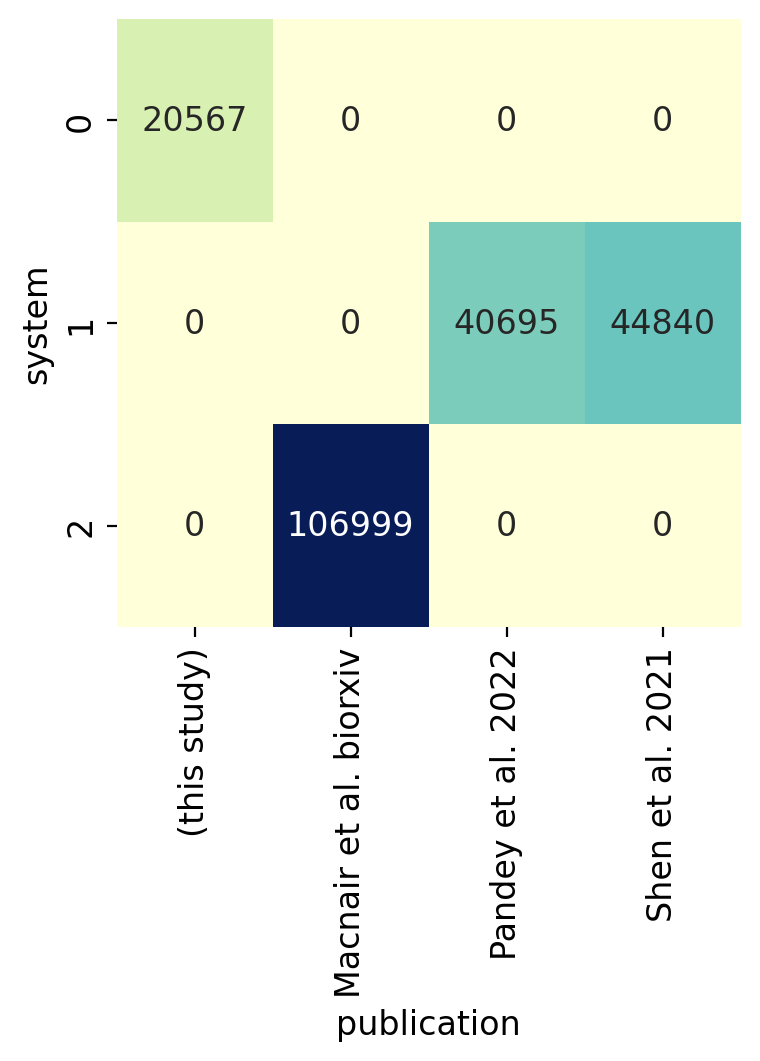

In [64]:
crosstab_df = pd.crosstab(adata_balanced.obs.system, adata_balanced.obs.publication)

# Create the heatmap with integer annotations
sb.heatmap(crosstab_df, cmap="YlGnBu", annot=True, fmt="d", cbar=False)

# Show the heatmap
plt.show()

In [65]:
adata_balanced.obs['organism'].value_counts()

organism
human    106999
mouse    106102
Name: count, dtype: int64

# Initiate model

In [66]:
adata_balanced

AnnData object with n_obs × n_vars = 213101 × 1796
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map'
    layers: 'counts', 'log1p_norm'

In [67]:
# Setup adata for training
SysVI.setup_anndata(
    adata=adata_balanced,
    batch_key="system",
    categorical_covariate_keys=["batch"],
)

INFO     Using column names from columns of adata.obsm['system']                                                   
INFO     Using column names from columns of adata.obsm['covariates']                                               


In [68]:
# Initialise the model
model = SysVI(adata=adata_balanced)

INFO     The model has been initialized                                                                            


In [69]:
# Train
max_epochs = 200
model.train(
    max_epochs=max_epochs,
    # Parameters used for checking losses
    log_every_n_steps=1,
    check_val_every_n_epoch=1,
    val_check_interval=1.0,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
You are using a CUDA device ('NVIDIA A10') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/afs

Epoch 200/200: 100%|███████████████████████████████████████████████████████████████████| 200/200 [58:22<00:00, 17.53s/it, v_num=1, loss_train=-936]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|███████████████████████████████████████████████████████████████████| 200/200 [58:22<00:00, 17.51s/it, v_num=1, loss_train=-936]


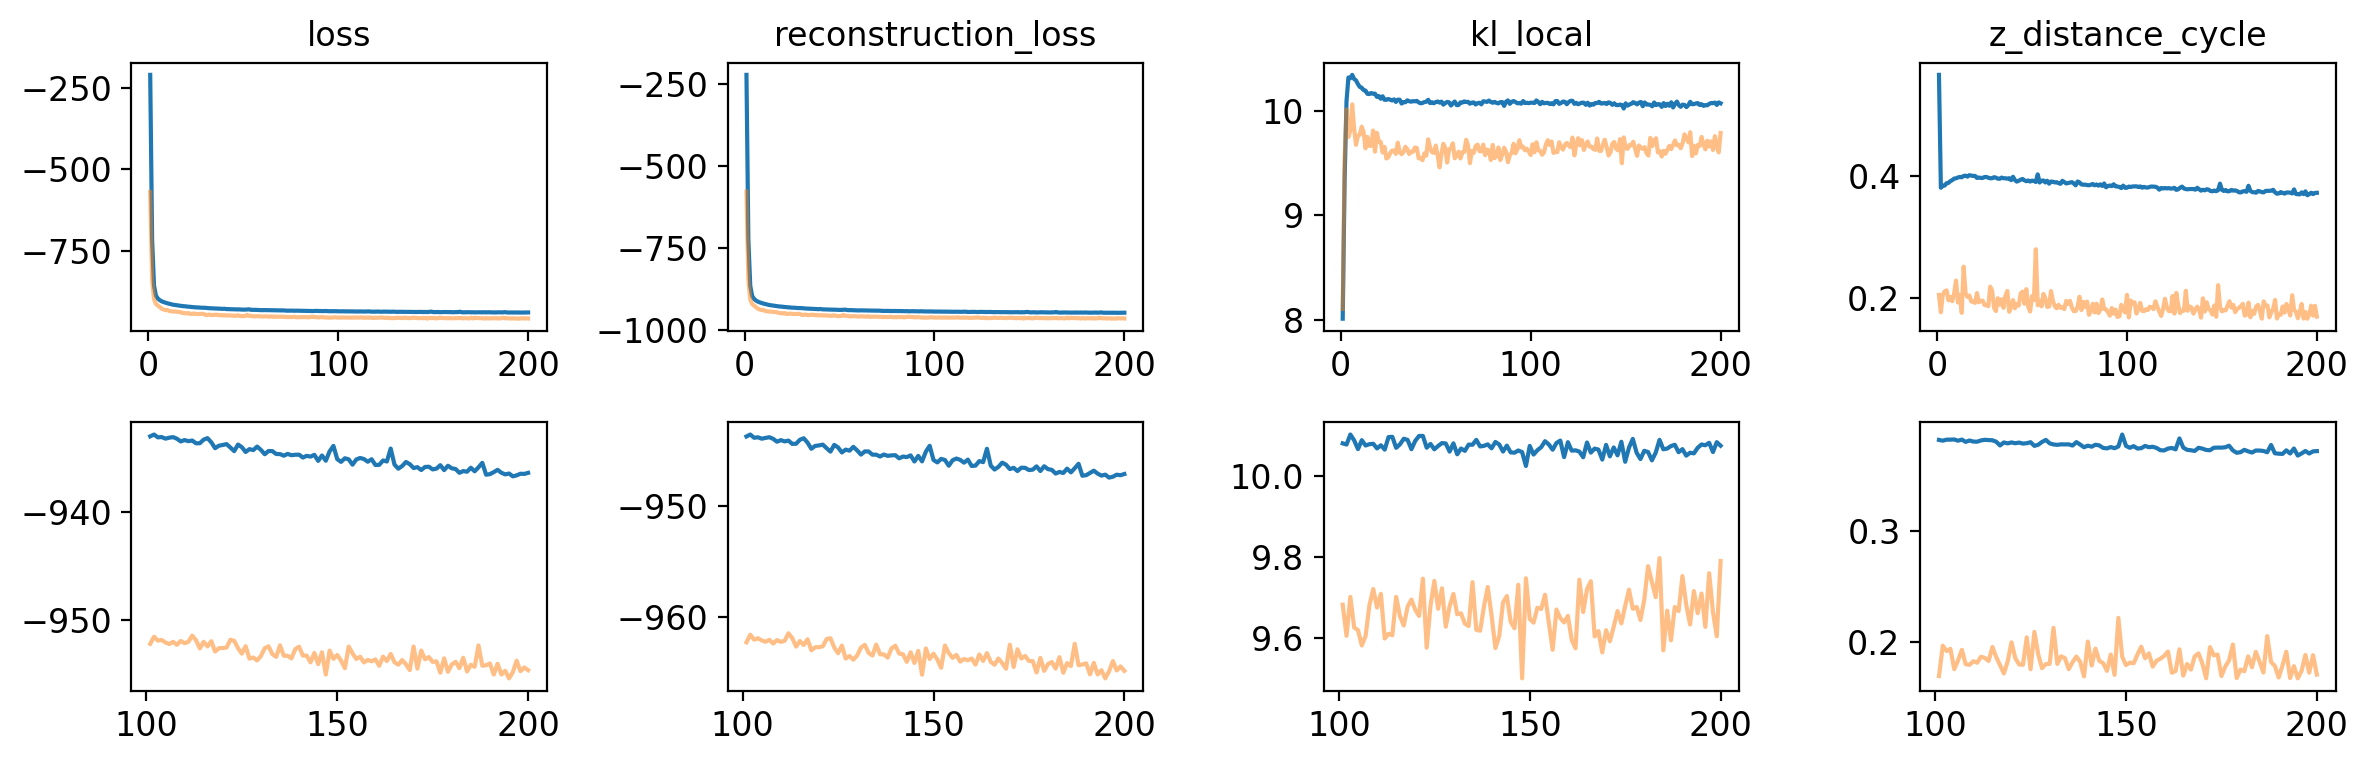

In [70]:
# Plot loses
# The plotting code below was specifcally adapted to the above specified model and its training
# If changing the model or training the plotting functions may need to be addapted accordingly

# Make detailed plot after N epochs
epochs_detail_plot = 100
steps_detail_plot = epochs_detail_plot * int(
    model.trainer.logger.history["loss_validation"].shape[0] / max_epochs
)
detail_plot = epochs_detail_plot

# Losses to plot
losses = [
    "loss_train",
    "reconstruction_loss_train",
    "kl_local_train",
    "z_distance_cycle_train",
]
fig, axs = plt.subplots(2, len(losses), figsize=(len(losses) * 3, 4))
for ax_i, l_train in enumerate(losses):
    l_val = l_train.replace("_train", "_validation")
    l_name = l_train.replace("_train", "")
    # Change idx of epochs to start with 1 so that below adjustment when
    # train on step which only works for val leads to appropriate multiplication
    l_val_values = model.trainer.logger.history[l_val].copy()
    l_val_values.index = l_val_values.index + 1
    l_train_values = model.trainer.logger.history[l_train].copy()
    l_train_values.index = l_train_values.index + 1
    # This happens if log on step as currently this works only for val loss
    if l_train_values.shape[0] < l_val_values.shape[0]:
        l_train_values.index = l_train_values.index * int(
            l_val_values.shape[0] / l_train_values.shape[0]
        )
    for l_values, c, alpha, dp in [
        # Train loss logged on epoch in either case now
        (l_train_values, "tab:blue", 1, epochs_detail_plot),
        (l_val_values, "tab:orange", 0.5, detail_plot),
    ]:
        axs[0, ax_i].plot(l_values.index, l_values.values.ravel(), c=c, alpha=alpha)
        axs[0, ax_i].set_title(l_name)
        axs[1, ax_i].plot(
            l_values.index[dp:], l_values.values.ravel()[dp:], c=c, alpha=alpha
        )

fig.tight_layout()

In [71]:
# Get embedidng - save it into X of new AnnData
embed = model.get_latent_representation(adata=adata_balanced)
embed = sc.AnnData(embed, obs=adata_balanced.obs)
# Make system categorical for plotting below
embed.obs["sysVI"] = embed.obs["system"].map({0: "mouse-sn", 1: "mouse-sc", 2: "human-sn"})

In [72]:
embed

AnnData object with n_obs × n_vars = 213101 × 15
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map', 'sysVI'

In [ ]:
# Compute UMAP
sc.pp.neighbors(embed, use_rep="X")
sc.tl.umap(embed)

In [ ]:
embed.obs

In [ ]:
# Plot UMAP embedding

# Obs columns to color by
cols = ["system", "cell_type_eval"]

# One plot per obs column used for coloring
fig, axs = plt.subplots(len(cols), 1, figsize=(3, 3 * len(cols)))
for col, ax in zip(cols, axs):
    sc.pl.embedding(
        embed,
        "X_umap",
        color=col,
        s=10,
        ax=ax,
        show=False,
        sort_order=False,
        frameon=False,
    )

In [ ]:
# Plot UMAP embedding per system
systems = sorted(embed.obs.sysVI.unique())
ncols = len(systems)
# Plot systems side by side
fig, axs = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
for i, system in enumerate(systems):
    ax = axs[i]
    # Plot all cells as background and on top cells from one system colored by cell type
    sc.pl.umap(embed, ax=ax, show=False, s=5, frameon=False)
    sc.pl.umap(
        embed[embed.obs.sysVI == system, :],
        color="cell_type_eval",
        ax=ax,
        show=False,
        s=10,
        frameon=False,
        title=system,  # Fix: Use `system` instead of `systems`
    )
    # Keep legend only on the last plot (assuming this legend contains all categories)
    if i != ncols - 1:
        ax.get_legend().remove()

In [ ]:
# Plot UMAP embedding per system
systems = sorted(embed.obs.sysVI.unique())
ncols = len(systems)
# Plot systems side by side
fig, axs = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
for i, system in enumerate(systems):
    ax = axs[i]
    # Plot all cells as background and on top cells from one system colored by cell type
    sc.pl.umap(embed, ax=ax, show=False, s=5, frameon=False)
    sc.pl.umap(
        embed[embed.obs.sysVI == system, :],
        color="cell_type_eval",
        ax=ax,
        show=False,
        s=2,
        frameon=False,
        title=system,  # Fix: Use `system` instead of `systems`
    )
    # Keep legend only on the last plot (assuming this legend contains all categories)
    if i != ncols - 1:
        ax.get_legend().remove()

# Alternate- adapt the adata directly like in scVI

In [ ]:
adata_balanced

In [73]:
SYSVI_LATENT_KEY = "X_sysVI"
adata_balanced.obsm[SYSVI_LATENT_KEY] = model.get_latent_representation(adata=adata_balanced)

In [74]:
sc.pp.neighbors(adata_balanced, use_rep = 'X_sysVI', n_neighbors=40) #can go up if the dataset is very large, #15, inc shows more broad structure
sc.tl.umap(adata_balanced, min_dist=0.25) #increase min_dist gives less detailed general features, #0.5

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:03:53)


In [75]:
#sc.tl.leiden(adata_balanced, resolution=0.5, key_added="sys_leiden_0.5")
sc.tl.leiden(adata_balanced, resolution=1, key_added="sys_leiden_1")
#sc.tl.leiden(adata_balanced, resolution=1.5, key_added="sys_leiden_1.5")
#sc.tl.leiden(adata_balanced, resolution=2, key_added="sys_leiden_2")

running Leiden clustering
    finished: found 28 clusters and added
    'sys_leiden_1', the cluster labels (adata.obs, categorical) (0:23:14)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seei

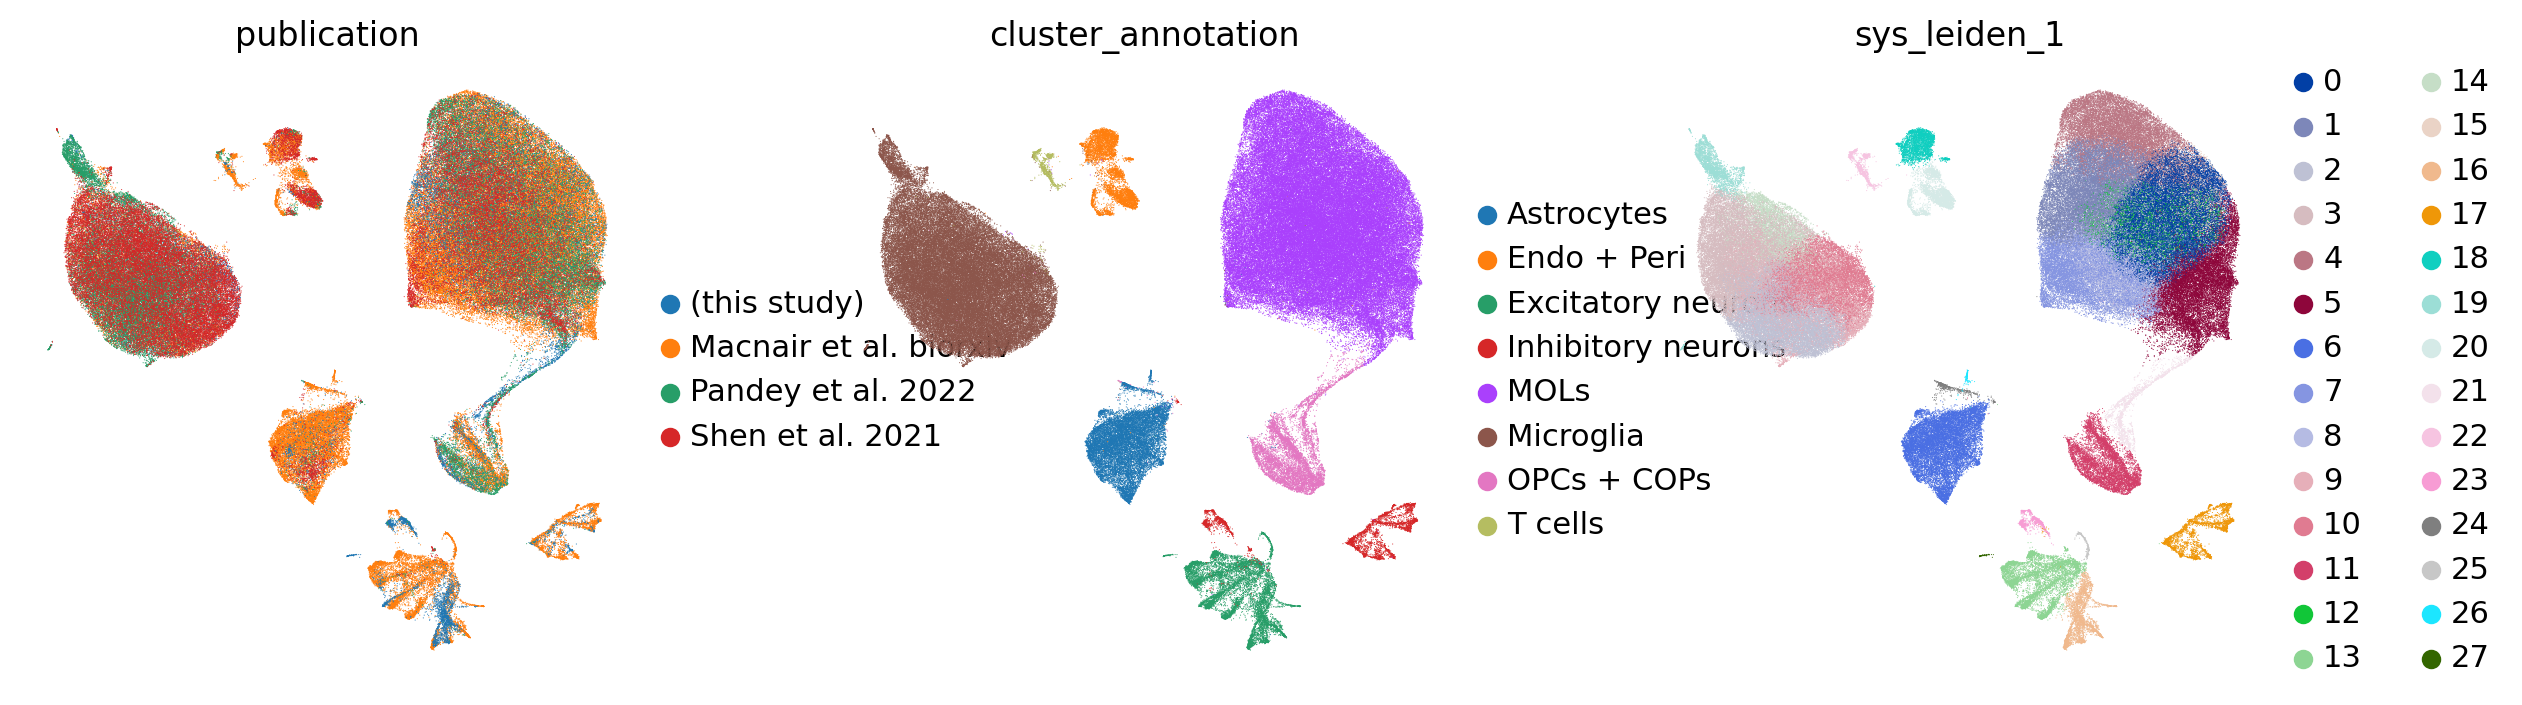

In [76]:
sc.pl.embedding(
    adata_balanced,
    basis='X_umap',
    color=["publication", "cluster_annotation", "sys_leiden_1"],
    frameon=False,
    ncols=3,
)

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/sc

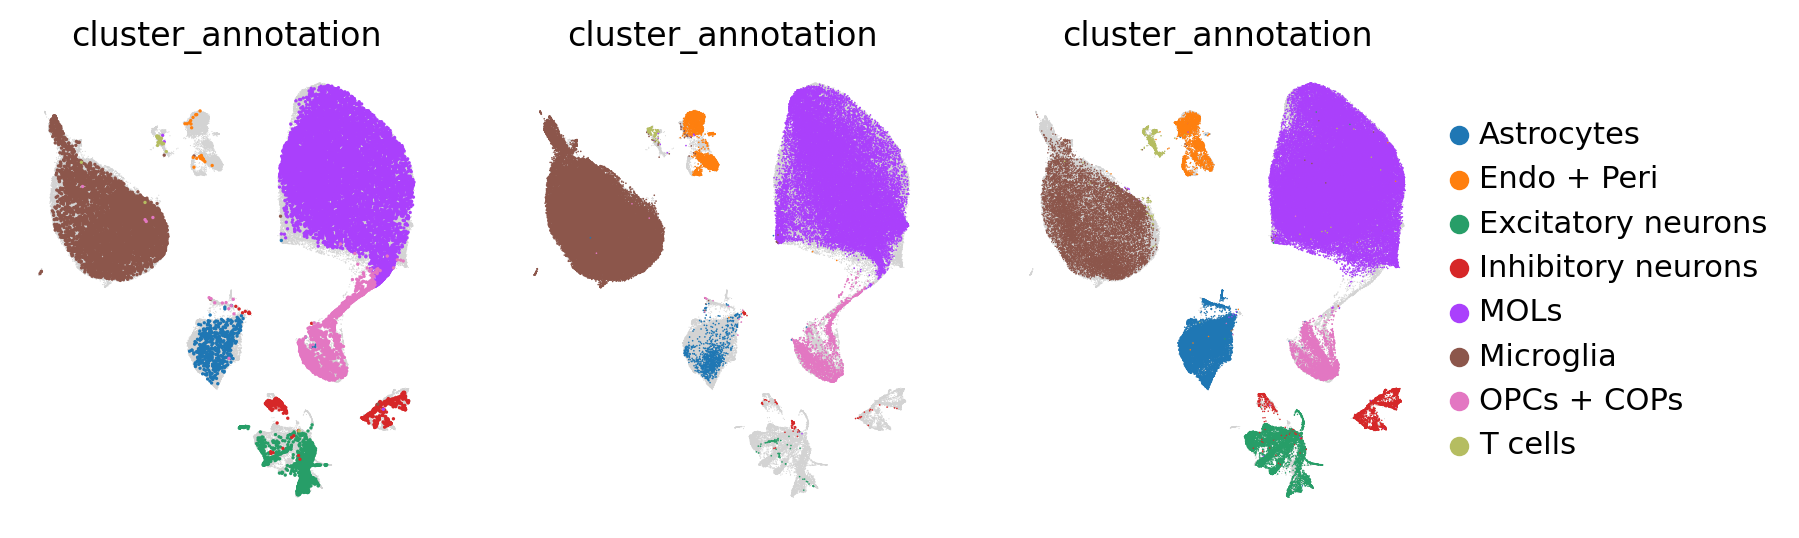

In [77]:
# Plot UMAP embedding per system
systems = sorted(adata_balanced.obs.system.unique())
ncols = len(systems)
# Plot systems side by side
fig, axs = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
for i, system in enumerate(systems):
    ax = axs[i]
    # Plot all cells as background and on top cells from one system colored by cell type
    sc.pl.umap(adata_balanced, ax=ax, show=False, frameon=False)
    sc.pl.umap(
        adata_balanced[adata_balanced.obs.system == system, :],
        color="cluster_annotation",
        ax=ax,
        show=False,
        frameon=False,
        #title=system,  # Fix: Use `system` instead of `systems`
    )
    # Keep legend only on the last plot (assuming this legend contains all categories)
    if i != ncols - 1:
        ax.get_legend().remove()

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


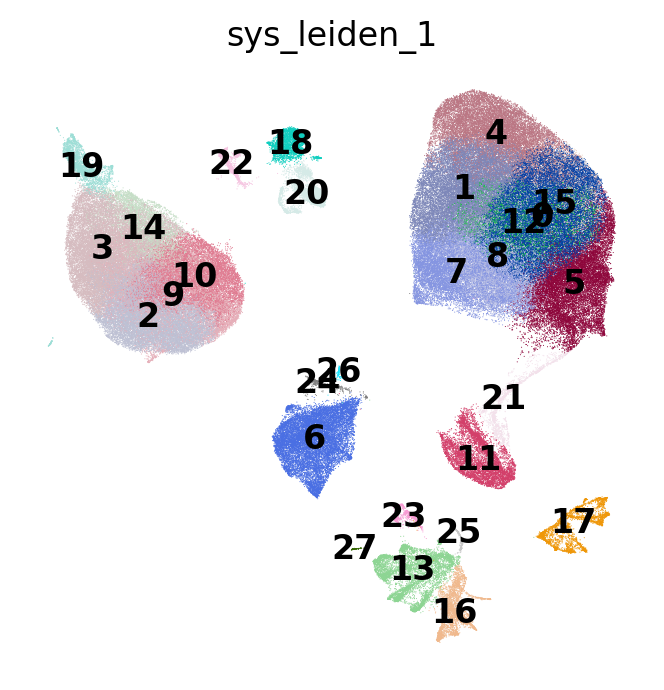

In [78]:
sc.pl.embedding(
    adata_balanced,
    basis='X_umap',
    color=["sys_leiden_1"],
    frameon=False,
    legend_loc='on data',
    ncols=1,
)

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seei

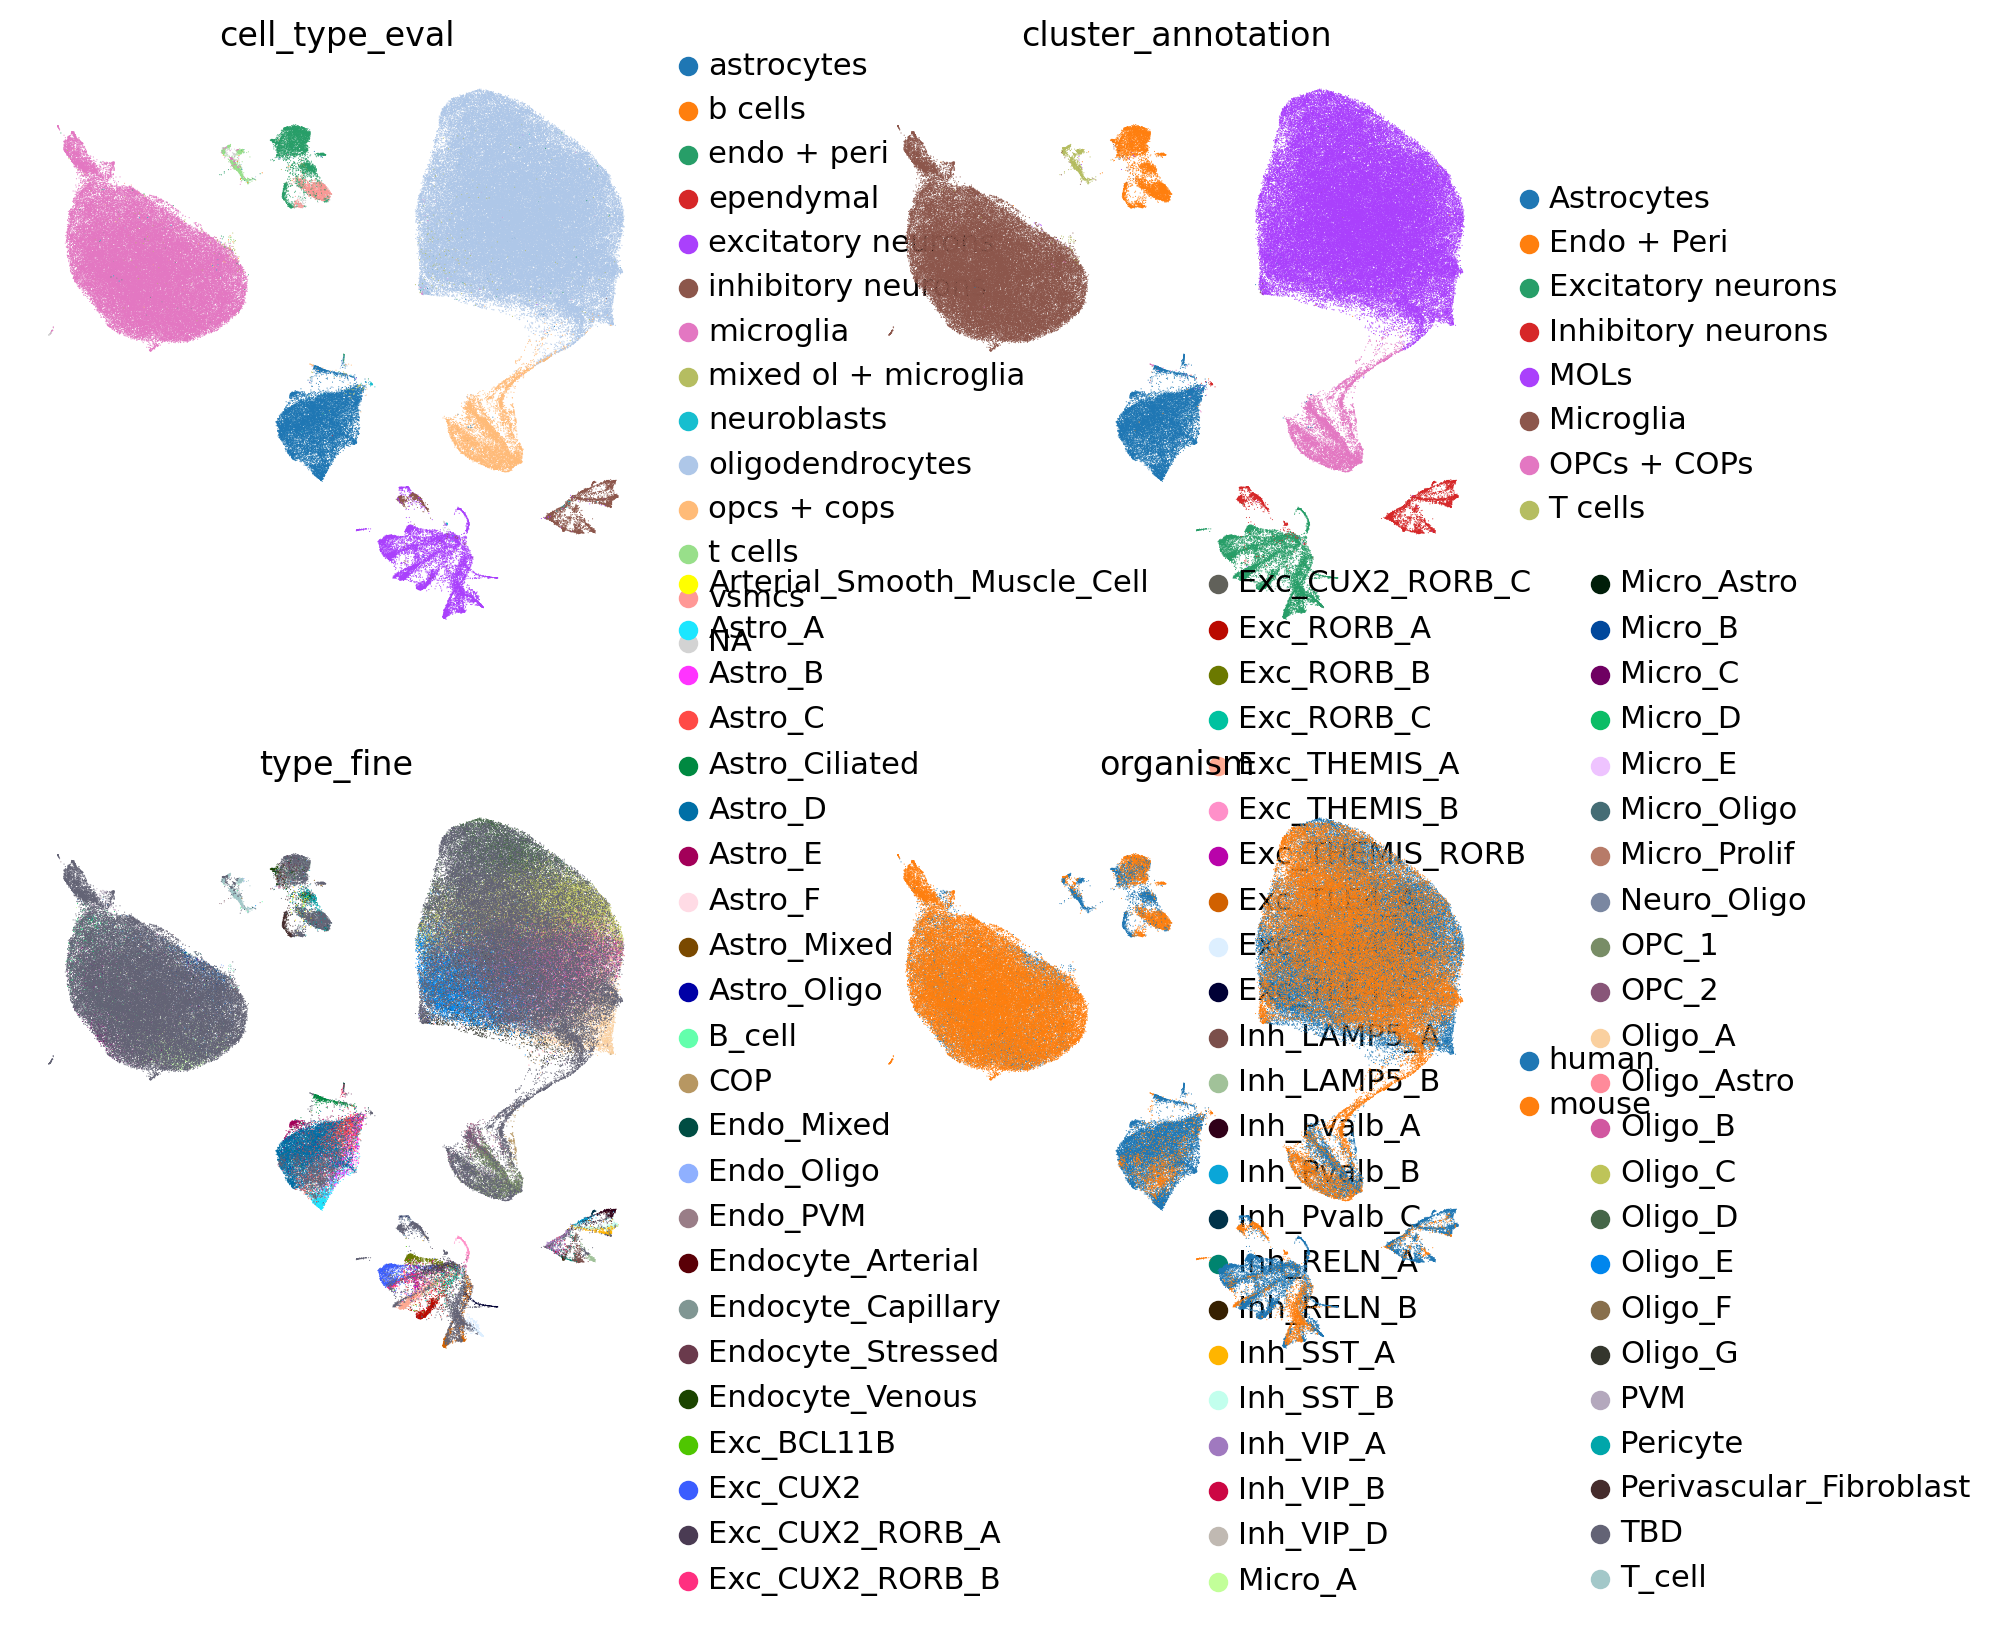

In [79]:
sc.pl.embedding(
    adata_balanced,
    basis='X_umap',
    color=["cell_type_eval", "cluster_annotation", "type_fine", 'organism'],
    frameon=False,
    ncols=2,
)

# Save work

In [ ]:
adata_balanced

In [ ]:
embed

In [80]:
model.save('sysVI_balanced_3kHVG.model')

In [81]:
model

cVAE model with optional VampPrior and latent cycle-consistency loss
Training status: Trained

In [ ]:
#model.save_state_dict('sysVI_balanced.pt')

In [82]:
system_data = adata_balanced.obsm['system']
print(system_data)

0    1    2
Ind98-Sample2:CTCCCTCGTACGAAAT-1_human  0.0  0.0  1.0
Ind98-Sample2:ATGGGAGCATACTGTG-1_human  0.0  0.0  1.0
Ind98-Sample2:CATGCGGTCGGATAAA-1_human  0.0  0.0  1.0
Ind98-Sample2:TGCGACGTCACTTGGA-1_human  0.0  0.0  1.0
Ind98-Sample2:TGCCGAGGTGTAACGG-1_human  0.0  0.0  1.0
...                                     ...  ...  ...
CCGTGGAAGATCTGAA-1_shen_mouse           0.0  1.0  0.0
GATCGTACACGCCAGT-1_shen_mouse           0.0  1.0  0.0
TCTCTAATCACCGTAA-1_shen_mouse           0.0  1.0  0.0
TCTCTAAGTCCGTTAA-1_shen_mouse           0.0  1.0  0.0
TCATTACTCTACGAGT-1_shen_mouse           0.0  1.0  0.0

[213101 rows x 3 columns]

In [83]:
adata_balanced.obsm['system']

,0,1,2
Ind98-Sample2:CTCCCTCGTACGAAAT-1_human,0.0,0.0,1.0
Ind98-Sample2:ATGGGAGCATACTGTG-1_human,0.0,0.0,1.0
Ind98-Sample2:CATGCGGTCGGATAAA-1_human,0.0,0.0,1.0
Ind98-Sample2:TGCGACGTCACTTGGA-1_human,0.0,0.0,1.0
Ind98-Sample2:TGCCGAGGTGTAACGG-1_human,0.0,0.0,1.0
...,...,...,...
CCGTGGAAGATCTGAA-1_shen_mouse,0.0,1.0,0.0
GATCGTACACGCCAGT-1_shen_mouse,0.0,1.0,0.0
TCTCTAATCACCGTAA-1_shen_mouse,0.0,1.0,0.0
TCTCTAAGTCCGTTAA-1_shen_mouse,0.0,1.0,0.0


In [84]:
# Change column names in obsm['system']
adata_balanced.obsm['system'].columns = ['mouse-sn', 'mouse-sc', 'human-sn']

In [85]:
adata_balanced.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/sysVI_h2m_balanced_output_3kHVG.h5ad')

In [ ]:
embed.write("/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/sysVI_embed_balanced_updatedHVG.h5ad")

# Get full representation?

In [86]:
adata

AnnData object with n_obs × n_vars = 422629 × 1796
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map'
    layers: 'counts', 'log1p_norm'

In [87]:
# Setup the full dataset (including cells not in balanced subset)

SysVI.setup_anndata(
    adata=adata,
    batch_key="system",
    categorical_covariate_keys=["batch"],
)

INFO     Using column names from columns of adata.obsm['system']                                                   
INFO     Using column names from columns of adata.obsm['covariates']                                               


In [88]:
SYSVI_LATENT_KEY = "X_sysVI"
adata.obsm[SYSVI_LATENT_KEY] = model.get_latent_representation(adata=adata)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [89]:
sc.pp.neighbors(adata, use_rep = 'X_sysVI', n_neighbors=40) #can go up if the dataset is very large, #15, inc shows more broad structure
sc.tl.umap(adata, min_dist=0.25) #increase min_dist gives less detailed general features, #0.5
#sc.tl.leiden(adata, resolution=0.5, key_added="sys_leiden_0.5")
sc.tl.leiden(adata, resolution=1, key_added="sys_leiden_1")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:35)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:10:21)
running Leiden clustering
    finished: found 34 clusters and added
    'sys_leiden_1', the cluster labels (adata.obs, categorical) (1:07:43)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seei

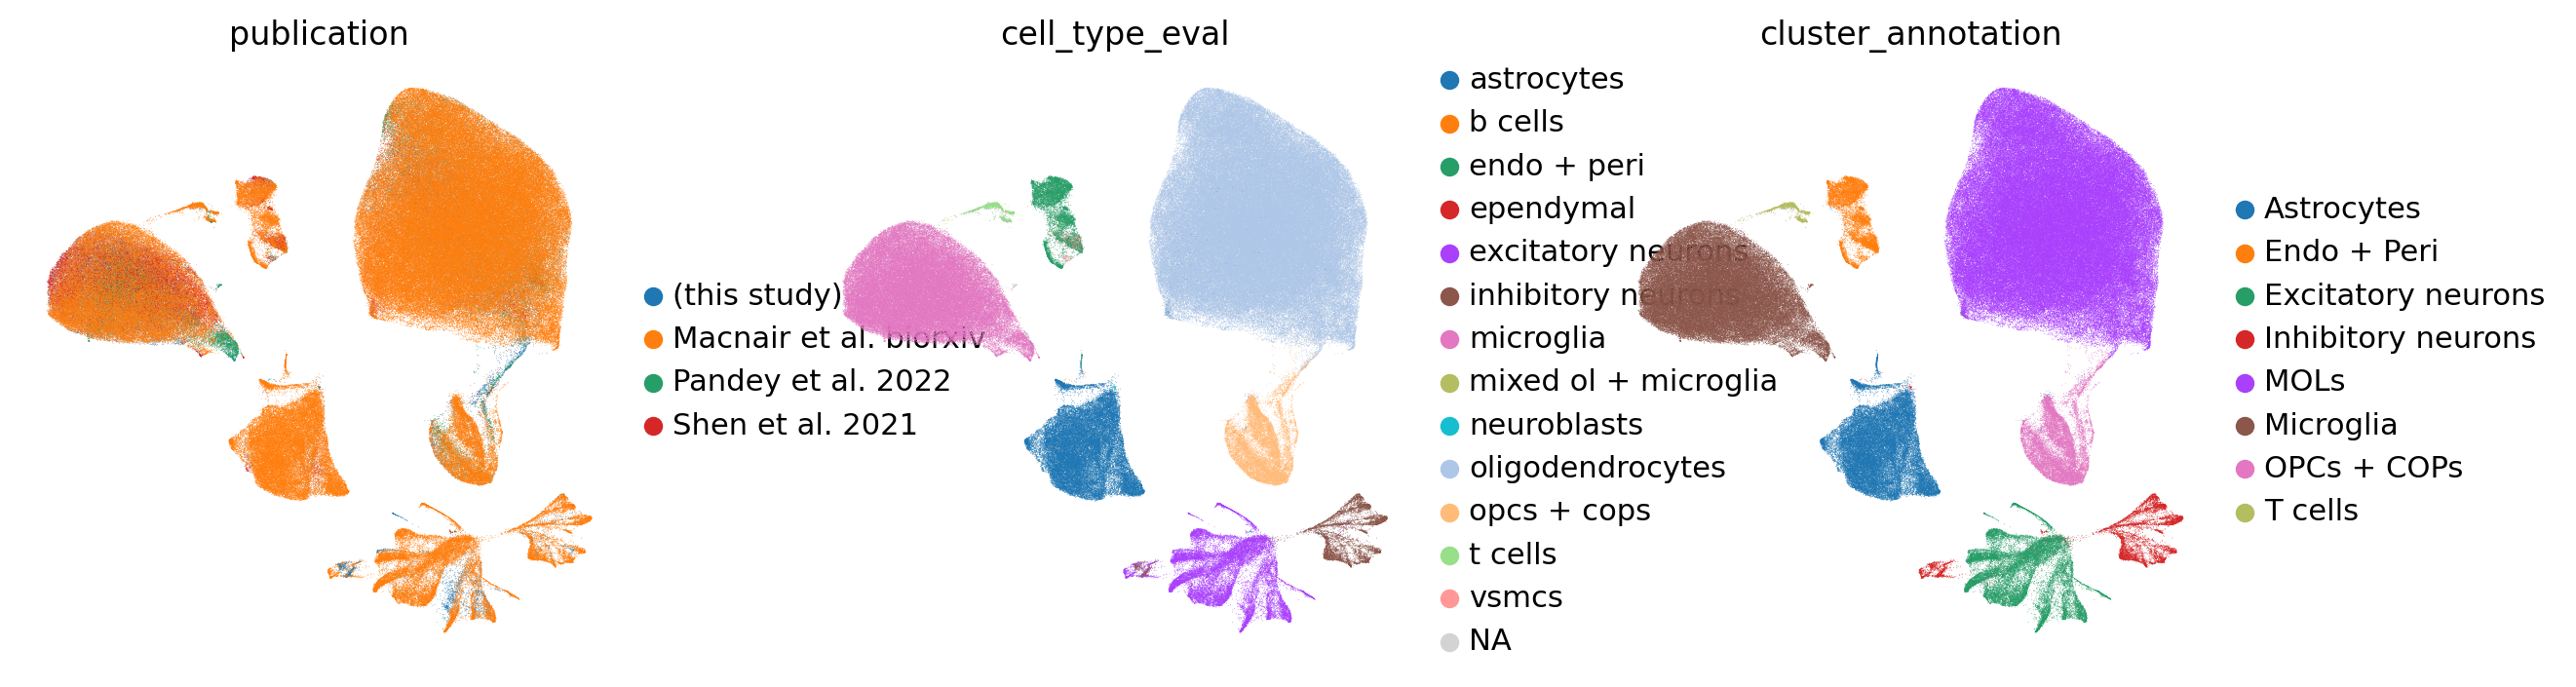

In [90]:
sc.pl.embedding(
    adata,
    basis='X_umap',
    color=["publication", "cell_type_eval", "cluster_annotation"],
    frameon=False,
    ncols=3,
)

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/sc

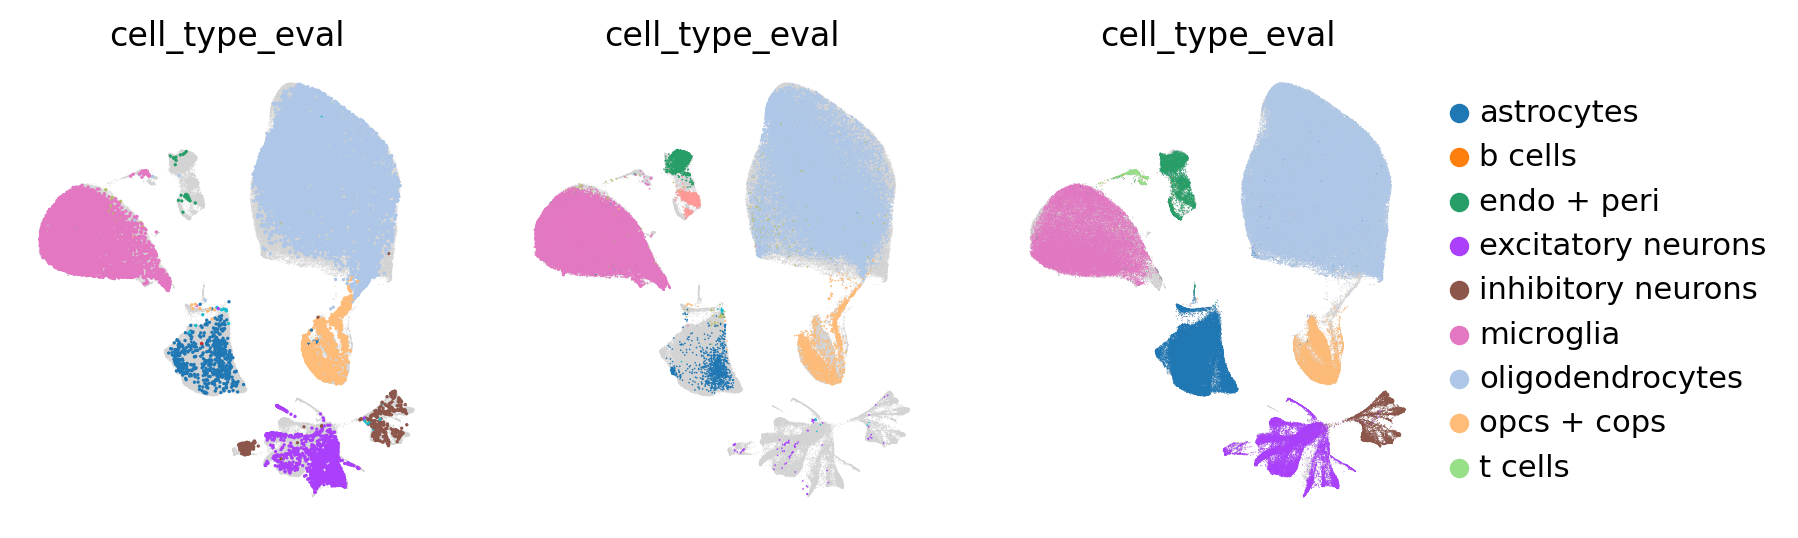

In [91]:
# Plot UMAP embedding per system
systems = sorted(adata.obs.system.unique())
ncols = len(systems)
# Plot systems side by side
fig, axs = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
for i, system in enumerate(systems):
    ax = axs[i]
    # Plot all cells as background and on top cells from one system colored by cell type
    sc.pl.umap(adata, ax=ax, show=False, frameon=False)
    sc.pl.umap(
        adata[adata.obs.system == system, :],
        color="cell_type_eval",
        ax=ax,
        show=False,
        frameon=False,
        #title=system,  # Fix: Use `system` instead of `systems`
    )
    # Keep legend only on the last plot (assuming this legend contains all categories)
    if i != ncols - 1:
        ax.get_legend().remove()

/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


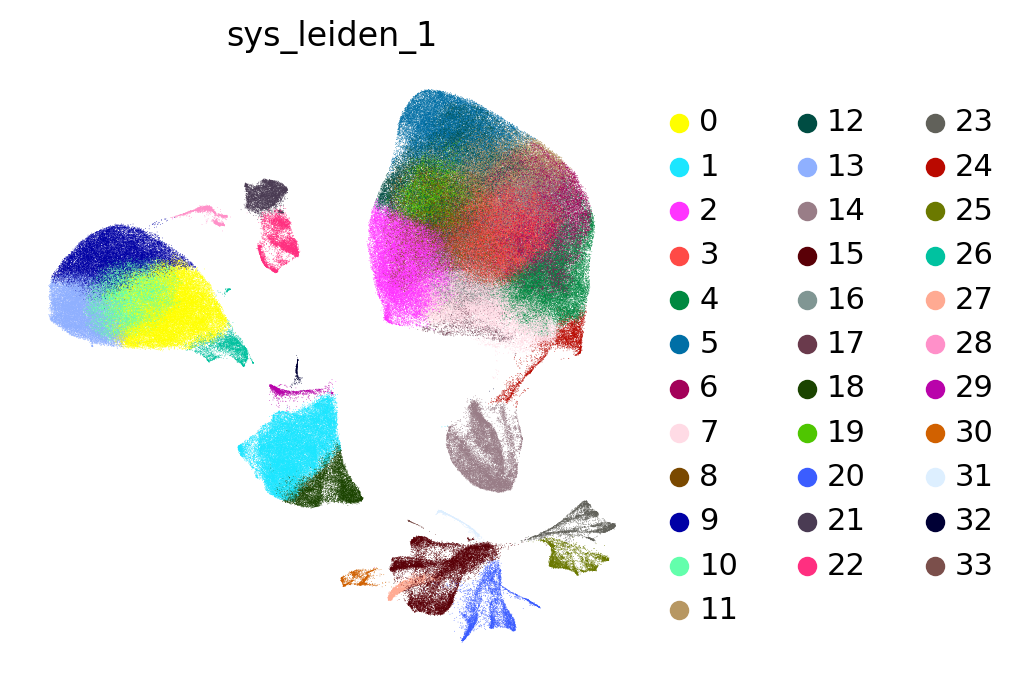

In [92]:
sc.pl.embedding(
    adata,
    basis='X_umap',
    color=["sys_leiden_1"],
    frameon=False,
    ncols=1,
)

In [93]:
# Change column names in obsm['system']
adata.obsm['system'].columns = ['mouse-sn', 'mouse-sc', 'human-sn']

In [94]:
adata.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/sysVI_h2m_balanced_ALL_output_3kHVG.h5ad')

# Make a prettier UMAP?

In [ ]:
sc.pp.neighbors(adata, use_rep = 'X_sysVI', n_neighbors=30) #can go up if the dataset is very large
sc.tl.umap(adata, min_dist=0.25) #increase min_dist reduces general features 

In [ ]:
# Plot UMAP embedding per system
systems = sorted(adata.obs.system.unique())
ncols = len(systems)
# Plot systems side by side
fig, axs = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
for i, system in enumerate(systems):
    ax = axs[i]
    # Plot all cells as background and on top cells from one system colored by cell type
    sc.pl.umap(adata, ax=ax, show=False, frameon=False)
    sc.pl.umap(
        adata[adata.obs.system == system, :],
        color="cell_type_eval",
        ax=ax,
        show=False,
        frameon=False,
        #title=system,  # Fix: Use `system` instead of `systems`
    )
    # Keep legend only on the last plot (assuming this legend contains all categories)
    if i != ncols - 1:
        ax.get_legend().remove()

# Subset to OL or MG

In [95]:
adata

AnnData object with n_obs × n_vars = 422629 × 1796
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map', 'sys_leiden_1'
    uns: 'layer_information', 'system_order', 'covariate_categ_orders', 'covariate_key_orders', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'publication_colors', 'cell_type_eval_colors', 'cluster_annotation_colors', 'sys_leiden_1_colors'
    obsm: 'system', 'covariat

In [96]:
adata.obs["cluster_annotation"].value_counts()

cluster_annotation
MOLs                  229433
Microglia              90700
Astrocytes             40945
Excitatory neurons     23683
OPCs + COPs            16425
Endo + Peri            10624
Inhibitory neurons      8970
T cells                 1849
Name: count, dtype: int64

In [97]:
desired_cell_types = ['MOLs', 'OPCs + COPs']
adata_ol = adata[adata.obs['cluster_annotation'].isin(desired_cell_types)].copy()
sc.pp.filter_genes(adata_ol, min_cells=3)
adata_ol

AnnData object with n_obs × n_vars = 245858 × 1796
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map', 'sys_leiden_1'
    var: 'n_cells'
    uns: 'layer_information', 'system_order', 'covariate_categ_orders', 'covariate_key_orders', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'publication_colors', 'cell_type_eval_colors', 'cluster_annotation_colors', 'sys_leiden_1_colors'
    obsm: 

In [98]:
sc.pp.neighbors(adata_ol, use_rep = 'X_sysVI', n_neighbors=20) #can go up if the dataset is very large
sc.tl.umap(adata_ol, min_dist=0.2) #increase min_dist reduces general features 

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:29)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:03:26)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


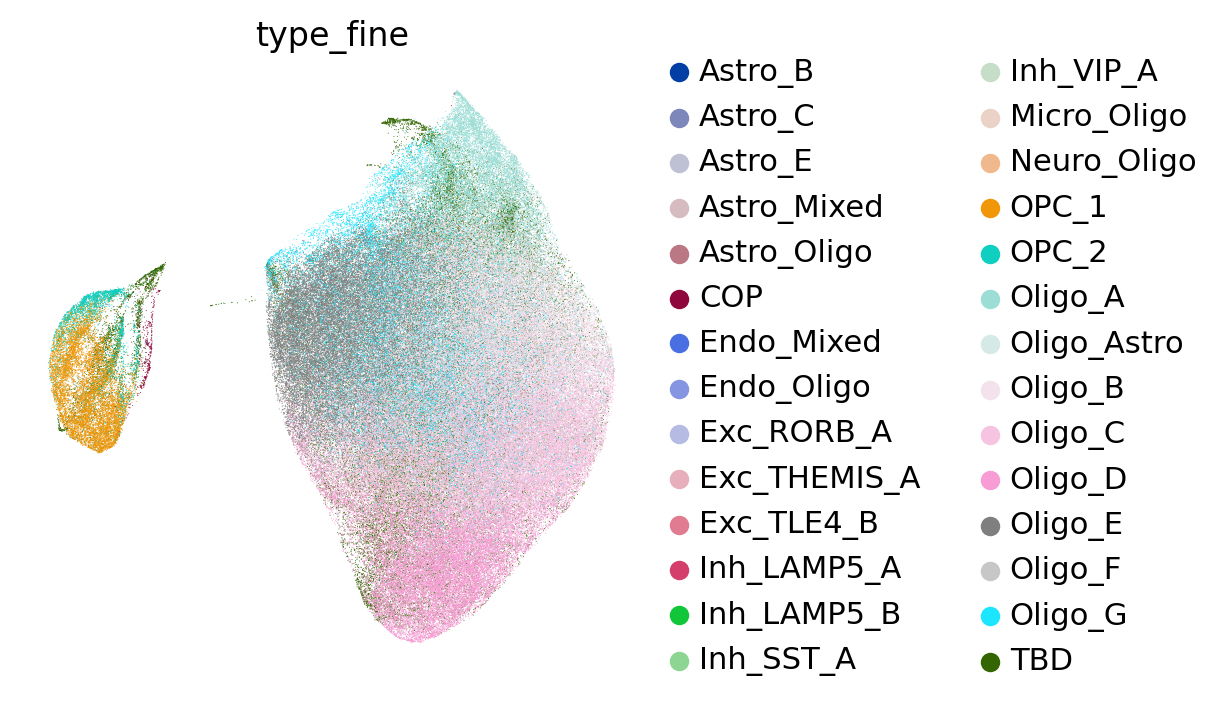

In [99]:
sc.pl.embedding(
    adata_ol,
    basis='X_umap',
    color=["type_fine"],
    frameon=False,
    ncols=1,
)

In [100]:
adata_ol.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/sysVI_h2m_balanced_OL_3kHVG.h5ad')

In [101]:
desired_cell_types = ['Microglia']
adata_mg = adata[adata.obs['cluster_annotation'].isin(desired_cell_types)].copy()
sc.pp.filter_genes(adata_mg, min_cells=3)
adata_mg

AnnData object with n_obs × n_vars = 90700 × 1796
    obs: 'sample_id', 'publication', 'sample_id_anon', 'individual_id_anon', 'replicate', 'treatment', 'condition', 'tissue', 'time', 'batch', 'lesion_type', 'sample_source', 'diagnosis', 'n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'type_fine', 'type_broad', 'exclude_pseudobulk', 'seq_pool', 'sex', 'age_at_death', 'smoker', 'cause_of_death', 'years_w_ms', 'pmi_minutes', 'age_scale', 'age_cat', 'pmi_cat', 'pmi_cat2', 'cell_type_eval', 'library_type', 'sample_type', 'organism', 'system', 'S_score', 'G2M_score', 'Cycling cells', 'Cycling_cells', 'cluster_annotation', 'refined_cluster_annotation', 'system_map', 'sys_leiden_1'
    var: 'n_cells'
    uns: 'layer_information', 'system_order', 'covariate_categ_orders', 'covariate_key_orders', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden', 'publication_colors', 'cell_type_eval_colors', 'cluster_annotation_colors', 'sys_leiden_1_colors'
    obsm: '

In [102]:
sc.pp.neighbors(adata_mg, use_rep = 'X_sysVI', n_neighbors=10) #can go up if the dataset is very large
sc.tl.umap(adata_mg, min_dist=0.5) #increase min_dist reduces general features 

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:40)


/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/afs/crc.nd.edu/user/e/eaboelno/miniforge3/envs/sysVI/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


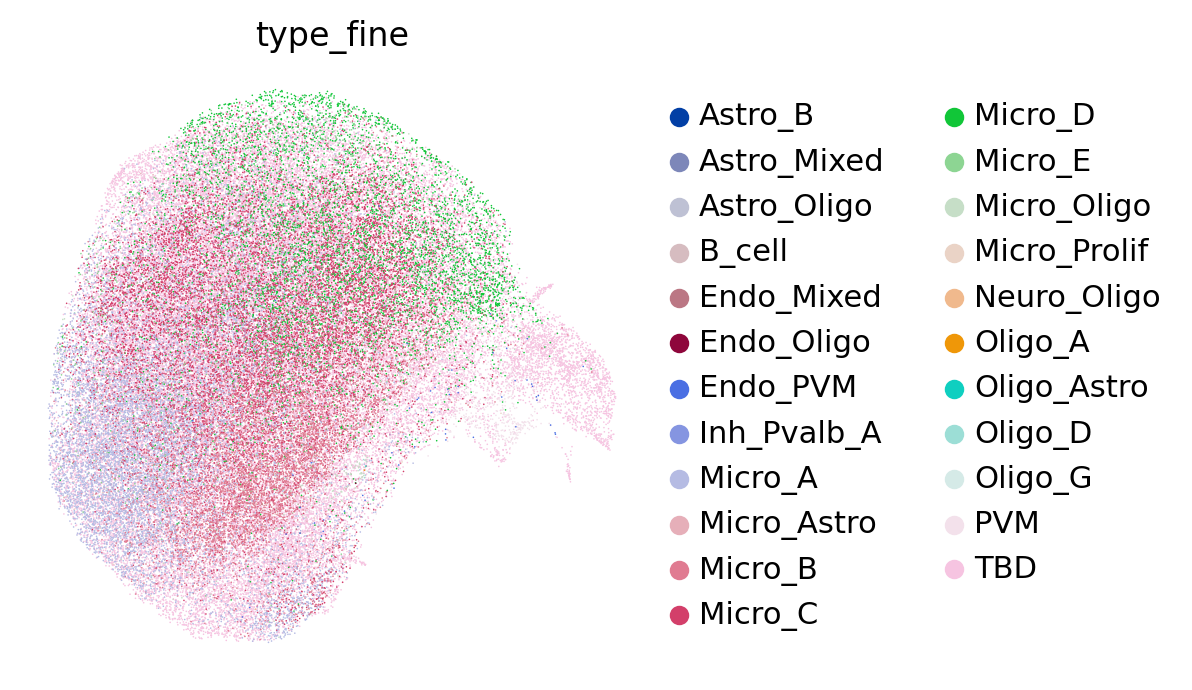

In [103]:
sc.pl.embedding(
    adata_mg,
    basis='X_umap',
    color=["type_fine"],
    frameon=False,
    ncols=1,
)

In [104]:
adata_mg.write_h5ad('/groups/kadams23/eaboelno/h5ad_backup/H2M_conversion/sysVI_h2m_balanced_MG_3kHVG.h5ad')